# Análisis Exploratorio de Datos del Proceso Productivo

**Máster en Proyectos de Datos Masivos y Ciencia de Datos**

Este notebook presenta el análisis exploratorio de los datos utilizados en el desarrollo del Trabajo Fin de Máster. El objetivo es conocer la estructura, calidad y comportamiento de los conjuntos de datos correspondientes a la producción y a los tiempos de paro del proceso de fabricación de tubos cerámicos, estableciendo una base para las posteriores etapas de preparación, integración y análisis de la información.


## 1. Importación de librerías

En esta sección se importan las librerías que serán utilizadas durante el análisis exploratorio. Estas herramientas permiten realizar la manipulación de los datos, generar estadísticas descriptivas y construir visualizaciones que facilitan la comprensión de la información contenida en los conjuntos de datos.

In [ ]:
# IMPORTACIÓN DE LIBRERÍAS

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

plt.style.use('default')
sns.set_theme(style="whitegrid")

## 2. Carga de los conjuntos de datos

En esta etapa se cargan los dos conjuntos de datos utilizados en el proyecto:

* **Producción**, que contiene información relacionada con el proceso productivo.
* **Tiempos de paro**, que registra las interrupciones de la producción, incluyendo su duración, motivo y equipo asociado.

Durante la carga también se realiza la conversión y normalización de las variables de fecha, con el fin de disponer de un formato adecuado para el análisis exploratorio y la posterior integración de la información.

In [ ]:
# 2. CARGA DE LOS DATASETS

ruta_produccion = "PROD2024_2026 PAV.csv"
ruta_paros = "TM2024_2026 PAV.csv"

# Cargar dataset de producción
df_produccion = pd.read_csv(
    ruta_produccion,
    encoding="latin-1",
    low_memory=False
)

# Cargar dataset de tiempos de paro
df_paros = pd.read_csv(
    ruta_paros,
    encoding="latin-1",
    low_memory=False
)


# CORRECCIÓN DE FECHA - PRODUCCIÓN

df_produccion["Fecha Turno"] = pd.to_datetime(
    df_produccion["Fecha Turno"],
    format="%d/%m/%Y",
    errors="coerce"
)

# Crear fecha normalizada para análisis e integración
df_produccion["Fecha"] = df_produccion["Fecha Turno"].dt.normalize()


# CORRECCIÓN DE FECHA - TIEMPOS DE PARO

df_paros["Fecha"] = (
    df_paros["Fecha"]
    .astype(str)
    .str.strip()
)

df_paros["Fecha"] = pd.to_datetime(
    df_paros["Fecha"],
    format="%d/%m/%Y",
    errors="coerce"
)

print("✅ Datasets cargados y fechas corregidas correctamente.")

✅ Datasets cargados y fechas corregidas correctamente.


## 3. Caracterización de los conjuntos de datos

Antes de realizar el análisis exploratorio, es necesario conocer la estructura y calidad de los conjuntos de datos. En esta sección se presentan las principales características de los datos de **Producción** y **Tiempos de paro**, incluyendo sus dimensiones, tipos de datos, valores nulos, registros duplicados y estadísticas descriptivas.

### 3.1 Resumen general de los conjuntos de datos

Como primer paso de la caracterización, se presenta un resumen de las principales características de los conjuntos de datos de **Producción** y **Tiempos de paro**. Este resumen permite conocer el volumen de información disponible y obtener una primera visión sobre la estructura y calidad de los datos antes de realizar un análisis más detallado.

In [ ]:
# Resumen general de los datasets

resumen = pd.DataFrame({
    "Dataset": ["Producción", "Tiempos de paro"],

    "Registros": [
        df_produccion.shape[0],
        df_paros.shape[0]
    ],

    "Variables": [
        df_produccion.shape[1],
        df_paros.shape[1]
    ],

    "Variables numéricas": [
        df_produccion.select_dtypes(include="number").shape[1],
        df_paros.select_dtypes(include="number").shape[1]
    ],

    "Variables categóricas": [
        df_produccion.select_dtypes(exclude="number").shape[1],
        df_paros.select_dtypes(exclude="number").shape[1]
    ],

    "Variables con valores nulos": [
        df_produccion.isna().any().sum(),
        df_paros.isna().any().sum()
    ],

    "Registros duplicados": [
        df_produccion.duplicated().sum(),
        df_paros.duplicated().sum()
    ]
})

# Formato para mejorar la visualización
for columna in resumen.columns[1:]:
    resumen[columna] = resumen[columna].map("{:,}".format)

display(resumen.style.hide(axis="index"))

Dataset,Registros,Variables,Variables numéricas,Variables categóricas,Variables con valores nulos,Registros duplicados
Producción,"127,297",52,38,14,4,41
Tiempos de paro,"169,442",15,3,12,6,"3,166"


### Interpretación

El conjunto de datos de Producción contiene 127,297 registros y 52 variables, mientras que Tiempos de paro contiene 169,442 registros y 15 variables. Esta diferencia refleja que ambos conjuntos presentan distintos niveles de detalle y responden a objetivos complementarios dentro del proceso productivo.

Los indicadores obtenidos muestran además la presencia de valores nulos y registros duplicados, por lo que es necesario profundizar en su revisión antes de realizar análisis posteriores. Estos aspectos se examinan en los siguientes apartados.

### 3.2 Estructura y tipos de datos

Una vez conocido el tamaño de los conjuntos de datos, se analiza la estructura de sus variables mediante la identificación de los tipos de datos presentes. Esta revisión permite verificar que cada variable tenga un formato adecuado para su posterior análisis y detectar posibles conversiones necesarias durante la etapa de preparación de los datos.

In [ ]:
# Resumen de tipos de datos

tipos = pd.DataFrame({
    "Tipo de dato": sorted(
        set(df_produccion.dtypes.astype(str))
        | set(df_paros.dtypes.astype(str))
    )
})

tipos["Producción"] = tipos["Tipo de dato"].apply(
    lambda x: (df_produccion.dtypes.astype(str) == x).sum()
)

tipos["Tiempos de paro"] = tipos["Tipo de dato"].apply(
    lambda x: (df_paros.dtypes.astype(str) == x).sum()
)

display(tipos.style.hide(axis="index"))

Tipo de dato,Producción,Tiempos de paro
datetime64[ns],2,1
float64,10,1
int64,28,2
object,12,11


### Interpretación

El conjunto de **Producción** presenta una mayor cantidad de variables numéricas, con **28 variables de tipo entero y 10 de tipo decimal**, además de variables categóricas y temporales. Por su parte, **Tiempos de paro** contiene principalmente variables categóricas, junto con variables numéricas y una variable temporal.

La estructura observada es coherente con la naturaleza de cada dataset: Producción concentra mediciones y cantidades del proceso, mientras que Tiempos de paro incorpora principalmente información de clasificación y descripción de los eventos.

### 3.3 Análisis de valores nulos

En este apartado se identifica la presencia de valores nulos en ambos conjuntos de datos. Su análisis permite detectar variables con información incompleta y evaluar si será necesario aplicar algún tratamiento durante la etapa de preparación de los datos.

In [ ]:
# Valores nulos por variable

nulos_produccion = (
    df_produccion.isna()
    .sum()
    .reset_index()
)

nulos_produccion.columns = ["Variable", "Valores nulos"]
nulos_produccion = nulos_produccion[nulos_produccion["Valores nulos"] > 0]
nulos_produccion["Porcentaje (%)"] = (
    nulos_produccion["Valores nulos"] / len(df_produccion) * 100
).round(2)

nulos_paros = (
    df_paros.isna()
    .sum()
    .reset_index()
)

nulos_paros.columns = ["Variable", "Valores nulos"]
nulos_paros = nulos_paros[nulos_paros["Valores nulos"] > 0]
nulos_paros["Porcentaje (%)"] = (
    nulos_paros["Valores nulos"] / len(df_paros) * 100
).round(2)

print("Producción")
display(nulos_produccion.style.hide(axis="index"))

print("Tiempos de paro")
display(nulos_paros.style.hide(axis="index"))

Producción


Variable,Valores nulos,Porcentaje (%)
Linea,54069,42.470000
Velocidad,23703,18.620000
Tipo de Registro,127253,99.970000
Observaciones,998,0.780000


Tiempos de paro


Variable,Valores nulos,Porcentaje (%)
Unnamed: 7,54199,31.990000
Unnamed: 8,54199,31.990000
Número de Aviso SAP,4348,2.570000
Observaciones,142936,84.360000
Unnamed: 13,164003,96.790000
Unnamed: 14,166316,98.160000


### Interpretación

En el conjunto de Producción se identificaron valores nulos en cuatro variables. Destaca Tipo de Registro, con 99.97 % de valores faltantes, seguida de Línea con 42.47 % y Velocidad con 18.62 %. Estos niveles de ausencia deberán considerarse durante la preparación de los datos, especialmente para las variables que sean necesarias para análisis posteriores.

En **Tiempos de paro** se observan valores nulos en las columnas **Unnamed: 7**, **Unnamed: 8**, **Unnamed: 13** y **Unnamed: 14**, además de **Número de Aviso SAP** y **Observaciones**. Las columnas `Unnamed` requieren una revisión de su origen para determinar si corresponden a campos sin información útil o a elementos derivados de la estructura original del archivo. Asimismo, el alto porcentaje de valores faltantes en **Observaciones (84.36 %)** deberá evaluarse antes de decidir su tratamiento o exclusión.

### 3.4 Análisis de registros duplicados

Los registros duplicados pueden afectar la confiabilidad de los análisis al representar observaciones repetidas dentro del conjunto de datos. En este apartado se identifica la cantidad de registros duplicados presentes en cada dataset para determinar si será necesario aplicar algún tratamiento durante la etapa de preparación de los datos.

In [ ]:
# Registros duplicados

duplicados = pd.DataFrame({
    "Dataset": ["Producción", "Tiempos de paro"],
    "Registros duplicados": [
        df_produccion.duplicated().sum(),
        df_paros.duplicated().sum()
    ]
})

duplicados["Registros duplicados"] = (
    duplicados["Registros duplicados"]
    .map("{:,}".format)
)

display(duplicados.style.hide(axis="index"))

Dataset,Registros duplicados
Producción,41
Tiempos de paro,"3,166"


### Interpretación

Se identificaron **41 registros duplicados** en el conjunto de datos de **Producción** y **3,166 registros duplicados** en **Tiempos de paro**. La presencia de registros repetidos indica la necesidad de revisar su origen durante la etapa de preparación de los datos, con el fin de determinar si corresponden a duplicados reales o a registros válidos generados por la operación del proceso.

### 3.5 Estadísticas descriptivas

Para caracterizar las principales variables cuantitativas de los datasets se calcularon medidas de tendencia central y dispersión: media, mediana, desviación estándar, mínimo y máximo.

La selección de variables se realizó considerando su utilidad para describir el comportamiento del proceso productivo y de los tiempos de paro. Por ello, no se incluyen variables categóricas codificadas numéricamente, identificadores de registros, contadores acumulativos ni variables cuyo valor solo resulta interpretable en función de un equipo específico.

En el caso de la velocidad, esta variable se conservará para análisis posteriores, pero no se utilizará en la caracterización descriptiva global, debido a que los equipos presentan escalas de operación diferentes. Su análisis se realizará posteriormente considerando el equipo o máquina correspondiente.

### 3.5.1 Estadísticas descriptivas de Producción

In [ ]:
# Estadísticas descriptivas de las principales variables productivas

variables_descriptivas_produccion = [
    "Piezas Prensadas",
    "M2 Prensados",
    "Piezas buenas prensadas a SAP",
    "M2 buenos prensados a SAP",
    "Piezas malas prensadas a SAP",
    "M2 malos prensados a SAP",
    "Piezas buenas esmaltadas a SAP",
    "M2 buenos esmaltados a SAP",
    "Piezas malas esmaltadas a SAP",
    "M2 malos esmaltados a SAP",
    "Piezas buenas entran al horno",
    "M2 buenos entran al horno",
    "Piezas Excluidas",
    "M2 Excluidas",
    "Tiempo operacion"
]

estadisticas_produccion = (
    df_produccion[variables_descriptivas_produccion]
    .describe()
    .T
)

estadisticas_produccion = estadisticas_produccion[
    ["mean", "50%", "std", "min", "max"]
]

estadisticas_produccion.columns = [
    "Media",
    "Mediana",
    "Desv. estándar",
    "Mínimo",
    "Máximo"
]

display(
    estadisticas_produccion.round(2)
)

,Media,Mediana,Desv. estándar,Mínimo,Máximo
Piezas Prensadas,1331.00,0.00,2897.59,-9824.00,17904.00
M2 Prensados,300.61,0.00,604.76,-1889.23,2399.36
Piezas buenas prensadas a SAP,1325.87,0.00,2888.10,-9824.00,17904.00
M2 buenos prensados a SAP,299.46,0.00,602.76,-1889.23,2399.36
Piezas malas prensadas a SAP,5.15,0.00,27.78,-46.00,1423.00
M2 malos prensados a SAP,1.16,0.00,5.75,-16.79,273.65
Piezas buenas esmaltadas a SAP,1309.60,0.00,3253.44,-9787.00,33138.00
M2 buenos esmaltados a SAP,295.77,0.00,721.50,-2460.39,4440.90
Piezas malas esmaltadas a SAP,16.26,0.00,57.36,-85.00,2290.00
M2 malos esmaltados a SAP,3.69,0.00,12.61,-26.29,537.79


### Interpretación

Las estadísticas descriptivas muestran una variabilidad considerable en las principales variables del proceso productivo. En varias de ellas existe una diferencia importante entre la media y la mediana, lo que indica una distribución asimétrica y la presencia de registros con valores elevados que influyen sobre el promedio.

Las variables de piezas y metros cuadrados permiten observar las diferentes etapas del proceso, desde el prensado hasta la entrada al horno, diferenciando además entre producción buena, producción mala y piezas excluidas.

Se identificaron valores mínimos negativos en distintas variables de producción. Debido a que estas variables representan cantidades que no pueden asumir valores negativos, estos registros corresponden a **errores de captura** y deberán ser tratados durante la etapa de limpieza de datos.

Por otra parte, **Tiempo operacion** presenta valores entre 0 y 480 minutos, por lo que será una variable relevante para analizar posteriormente el comportamiento operativo y su relación con los tiempos de paro.

### 3.5.2 Estadísticas descriptivas de los tiempos de paro

Para el dataset de tiempos de paro se seleccionó la variable Duración como medida principal de análisis, debido a que representa directamente el tiempo durante el cual se registra un evento de paro.

Se excluyeron variables como Turno, que representa una categoría operativa, y Número de Aviso SAP, que funciona como identificador del registro. Aunque ambas variables presentan valores numéricos, no representan magnitudes continuas sobre las cuales resulte significativo calcular medidas como la media o la desviación estándar.

In [ ]:
# Estadísticas descriptivas de la duración de los tiempos de paro

variables_descriptivas_paros = [
    "Duración"
]

estadisticas_paros = (
    df_paros[variables_descriptivas_paros]
    .describe()
    .T
)

estadisticas_paros = estadisticas_paros[
    ["mean", "50%", "std", "min", "max"]
]

estadisticas_paros.columns = [
    "Media",
    "Mediana",
    "Desv. estándar",
    "Mínimo",
    "Máximo"
]

display(
    estadisticas_paros.round(2)
)

,Media,Mediana,Desv. estándar,Mínimo,Máximo
Duración,16.43,10.00,36.32,0.00,480.00


### Interpretación

La duración de los eventos de paro presenta una **media de 16.43 minutos y una mediana de 10 minutos**, lo que indica una distribución con mayor concentración de eventos de corta duración y algunos paros prolongados que elevan el promedio.

La desviación estándar de **36.32 minutos** confirma una variabilidad considerable en la duración de los eventos. El rango observado, desde **0 hasta 480 minutos**, evidencia la existencia de paros con impactos operativos muy diferentes.

Por ello, en las siguientes etapas se analizará la duración de los paros según variables como **motivo, máquina y turno**, con el objetivo de identificar los factores que concentran el mayor impacto sobre la operación.

# 4. Análisis exploratorio del conjunto de datos de Producción

En esta sección se analiza el comportamiento del conjunto de datos de Producción con el objetivo de identificar patrones, tendencias y características relevantes del proceso productivo. El análisis se centra en las variables que aportan información para comprender el desempeño de la producción durante el periodo de estudio.

## 4.1 Preparación y verificación de las variables temporales

Para realizar el análisis temporal de la producción, se verifica que las variables **Fecha Turno** y **Fecha** se encuentren correctamente almacenadas en formato de fecha. Esta validación permitirá utilizar la información temporal para agrupar los registros y analizar la evolución de la producción durante el periodo de estudio.

In [ ]:
# 4.1 VERIFICACIÓN DE LA VARIABLE FECHA

print("VERIFICACIÓN DE LA FECHA DE PRODUCCIÓN")

print("Tipo Fecha Turno:")
print(df_produccion["Fecha Turno"].dtype)

print("\nTipo Fecha:")
print(df_produccion["Fecha"].dtype)

print("\nFecha mínima:")
print(df_produccion["Fecha"].min())

print("\nFecha máxima:")
print(df_produccion["Fecha"].max())

print("\nÚltimos registros:")
print(
    df_produccion[
        ["Fecha", "Fecha Turno", "Máquina", "Turno"]
    ].tail(20).to_string(index=False)
)

VERIFICACIÓN DE LA FECHA DE PRODUCCIÓN
Tipo Fecha Turno:
datetime64[ns]

Tipo Fecha:
datetime64[ns]

Fecha mínima:
2024-01-01 00:00:00

Fecha máxima:
2026-08-02 00:00:00

Últimos registros:
     Fecha Fecha Turno      Máquina  Turno
2026-08-02  2026-08-02      Horno 1      3
2026-08-02  2026-08-02 Prensa 7 New      3
2026-08-02  2026-08-02 Prensa 6 New      3
2026-08-02  2026-08-02  Linea 6 New      3
2026-08-02  2026-08-02      Horno 3      3
2026-08-02  2026-08-02     Prensa 9      3
2026-08-02  2026-08-02     Prensa 8      3
2026-08-02  2026-08-02      Línea 7      3
2026-08-02  2026-08-02     Prensa 1      3
2026-08-02  2026-08-02      Línea 1      3
2026-08-02  2026-08-02     Prensa 2      3
2026-08-02  2026-08-02      Línea 2      3
2026-08-02  2026-08-02     Prensa 3      3
2026-08-02  2026-08-02      Línea 3      3
2026-08-02  2026-08-02     Prensa 4      3
2026-08-02  2026-08-02      Línea 4      3
2026-08-02  2026-08-02     Prensa 5      3
2026-08-02  2026-08-02      Línea 5 

## 4.2 Evolución temporal de la producción

Con el objetivo de identificar el comportamiento de la producción a lo largo del tiempo, se analiza la evolución diaria de los metros cuadrados prensados (M²). Esta visualización permite detectar tendencias, variaciones y posibles cambios en el nivel de producción durante el periodo de estudio.

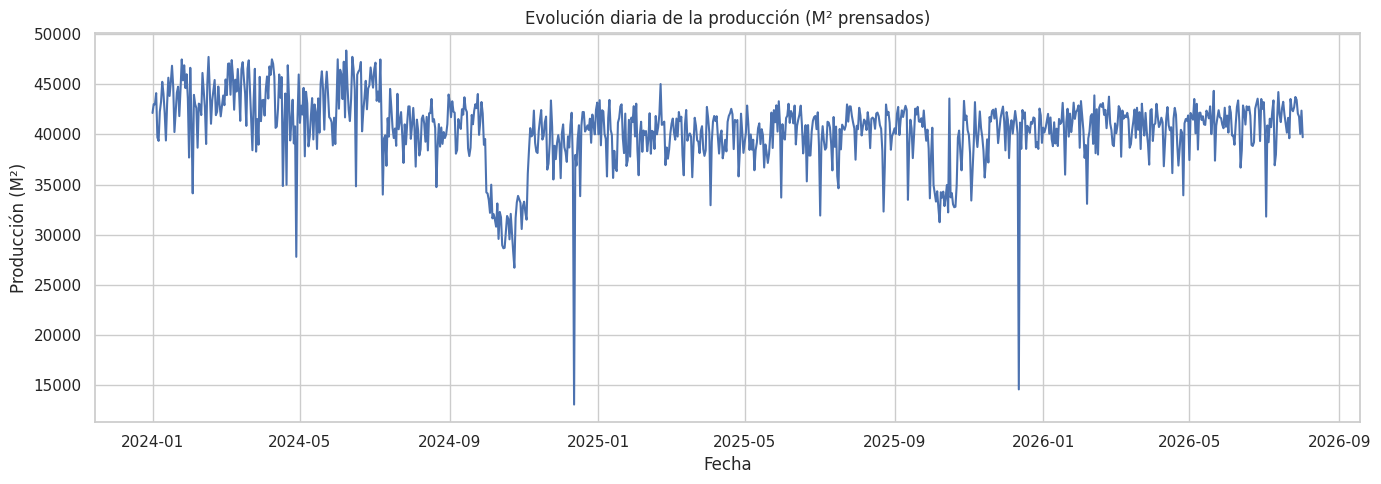

In [ ]:
# Producción diaria (M2 Prensados)
# Se excluyen registros negativos identificados como errores de captura.

produccion_diaria = (
    df_produccion[df_produccion["M2 Prensados"] >= 0]
    .groupby("Fecha Turno")["M2 Prensados"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(14,5))

plt.plot(
    produccion_diaria["Fecha Turno"],
    produccion_diaria["M2 Prensados"]
)

plt.title("Evolución diaria de la producción (M² prensados)")
plt.xlabel("Fecha")
plt.ylabel("Producción (M²)")

plt.tight_layout()
plt.show()

### Interpretación

La evolución diaria de la producción muestra una variabilidad considerable durante el periodo analizado. Durante 2024 se observan niveles de producción generalmente elevados, aunque con fluctuaciones importantes y una disminución más pronunciada hacia el último trimestre del año.

A partir de 2025, la producción presenta un comportamiento relativamente más estable, concentrándose principalmente alrededor de los 40,000–43,000 M² diarios. No se identifica una tendencia creciente o decreciente sostenida, sino fluctuaciones alrededor de un nivel de producción relativamente constante.

También se observan disminuciones puntuales de gran magnitud. Estos eventos deberán analizarse posteriormente en conjunto con los registros de tiempos de paro para determinar si están asociados con interrupciones relevantes del proceso productivo.

## 4.3 Producción promedio por turno

Con el propósito de identificar posibles diferencias en el desempeño de la producción entre los distintos turnos de trabajo, se analiza la distribución de los metros cuadrados prensados agrupados por turno.

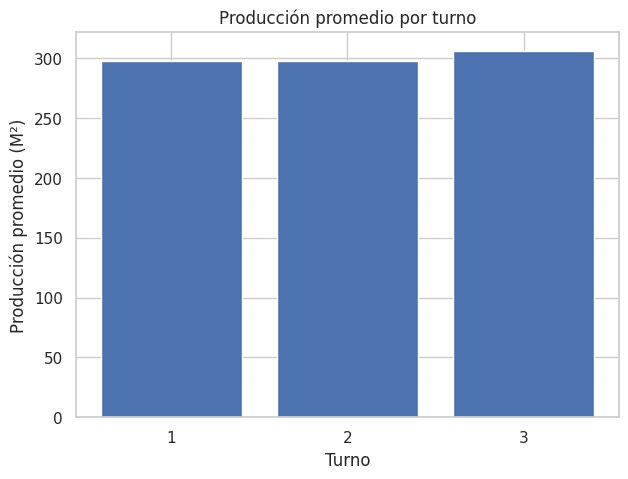

In [ ]:
# Producción promedio por turno

produccion_turno = (
    df_produccion[df_produccion["M2 Prensados"] >= 0]
    .groupby("Turno")["M2 Prensados"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(7,5))

plt.bar(
    produccion_turno["Turno"].astype(str),
    produccion_turno["M2 Prensados"]
)

plt.title("Producción promedio por turno")
plt.xlabel("Turno")
plt.ylabel("Producción promedio (M²)")

plt.show()

### Interpretación

La producción promedio presenta un comportamiento similar entre los tres turnos. Los turnos 1 y 2 muestran valores prácticamente iguales, mientras que el turno 3 presenta un promedio ligeramente superior.

En términos generales, las diferencias observadas son reducidas, por lo que no se identifica una variación significativa de la producción promedio asociada al turno. Esto sugiere que, a nivel agregado, el volumen producido se mantiene relativamente estable entre los diferentes periodos de trabajo.

## 4.4 Producción por producto

En este apartado se analiza el volumen acumulado de producción por producto terminado (Producto PT), utilizando los metros cuadrados prensados como medida de producción. Se identifican los diez productos con mayor volumen acumulado durante el periodo analizado, con el propósito de determinar cuáles concentran una mayor participación dentro de la producción registrada.

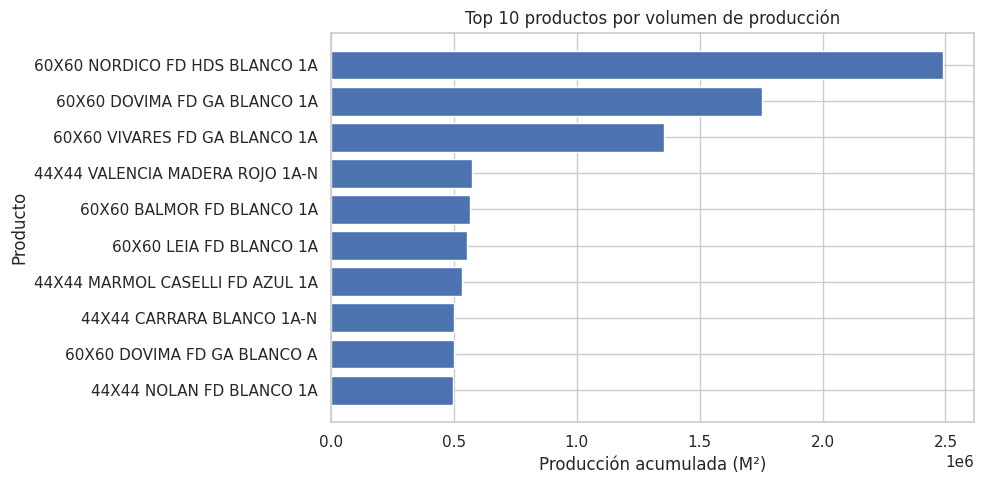

In [ ]:
# Top 10 productos con mayor producción

top_productos = (
    df_produccion
    .groupby("Producto PT")["M2 Prensados"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

plt.barh(
    top_productos.index,
    top_productos.values
)

plt.title("Top 10 productos por volumen de producción")
plt.xlabel("Producción acumulada (M²)")
plt.ylabel("Producto")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### Interpretación

El volumen acumulado de producción se concentra principalmente en algunos productos. El producto **60X60 NORDICO FD HDS BLANCO 1A** presenta el mayor volumen, con aproximadamente **2.5 millones de M²**, seguido por **60X60 DOVIMA FD GA BLANCO 1A** y **60X60 VIVARES FD GA BLANCO 1A**.

A partir del cuarto producto se observa una reducción considerable del volumen acumulado, mientras que los productos restantes del Top 10 presentan niveles relativamente similares.

Estos resultados muestran que una parte importante del volumen producido se concentra en determinados productos, por lo que su comportamiento puede tener una mayor influencia sobre los indicadores globales de producción.

## 4.5 Distribución de la velocidad

Se analiza la distribución de la variable **Velocidad** con el objetivo de conocer su comportamiento durante el periodo de estudio e identificar posibles concentraciones de valores o registros atípicos.

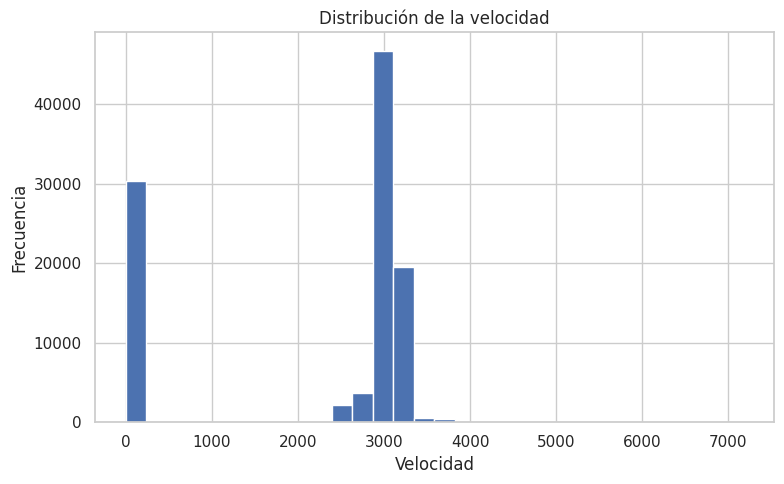

In [ ]:
# Distribución de la velocidad

plt.figure(figsize=(8,5))

plt.hist(
    df_produccion["Velocidad"].dropna(),
    bins=30
)

plt.title("Distribución de la velocidad")
plt.xlabel("Velocidad")
plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()

### Interpretación

La distribución de la variable **Velocidad** presenta un comportamiento heterogéneo, con una concentración importante de registros en valores bajos y otra agrupación alrededor de los 2,800–3,300.

También se observan valores alejados de las principales concentraciones, lo que indica la presencia de registros extremos que deberán revisarse antes de utilizar esta variable en análisis posteriores.

Debido a la presencia de valores nulos y a la concentración de registros en valores bajos, es necesario analizar el significado operativo de estos valores y determinar si corresponden a periodos sin producción, condiciones particulares del proceso o registros que requieren tratamiento durante la limpieza de datos.

## 4.6 Correlación entre variables productivas

En este apartado se analiza la relación lineal entre las principales variables cuantitativas relacionadas con el proceso de producción. Se consideran variables asociadas al volumen de piezas y metros cuadrados producidos, piezas buenas y malas registradas a SAP, tiempo de operación y velocidad.

El objetivo es identificar relaciones positivas o negativas entre estos indicadores y detectar variables que presenten comportamientos similares dentro del proceso productivo.

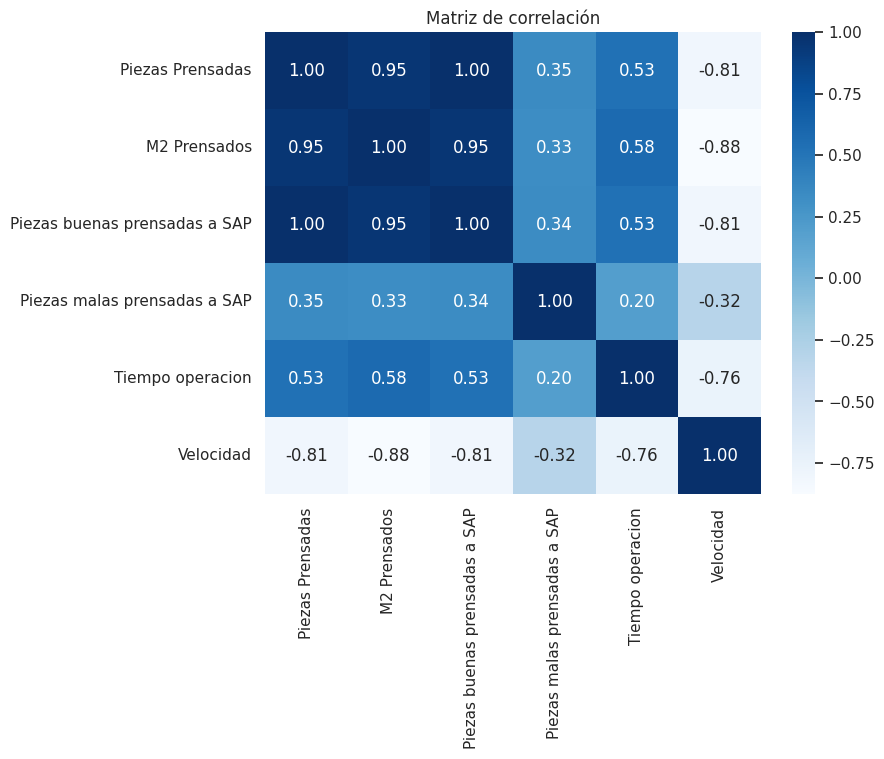

In [ ]:
variables_corr = [
    "Piezas Prensadas",
    "M2 Prensados",
    "Piezas buenas prensadas a SAP",
    "Piezas malas prensadas a SAP",
    "Tiempo operacion",
    "Velocidad"
]

correlacion = df_produccion[variables_corr].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    correlacion,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Matriz de correlación")

plt.show()

### Interpretación

La matriz de correlación muestra relaciones importantes entre algunas de las variables del proceso productivo.

Se observa una correlación positiva muy fuerte entre **Piezas Prensadas** y **M2 Prensados (0.95)**, así como entre **Piezas Prensadas** y **Piezas buenas prensadas a SAP (1.00)**. Estas relaciones son coherentes con el hecho de que las variables representan diferentes medidas asociadas al volumen de producción.

Por otra parte, **Tiempo operación** y **Velocidad** presentan una correlación negativa fuerte de **-0.77**. También se observa una correlación negativa moderada entre **M2 Prensados** y **Velocidad (-0.58)**.

La variable **Piezas malas prensadas a SAP** presenta correlaciones relativamente bajas con el resto de las variables, lo que indica que su comportamiento no está fuertemente asociado de manera lineal con estas variables.

Estas relaciones permiten identificar variables potencialmente relevantes para análisis posteriores, aunque una correlación no implica por sí misma una relación causal.

# 5. Análisis exploratorio del conjunto de datos de Tiempos de paro

En esta sección se analiza el comportamiento de los tiempos de paro registrados durante el periodo de estudio. El objetivo es identificar los principales factores que afectan la continuidad del proceso productivo mediante el análisis de la duración de los paros, los motivos, los procesos y los equipos involucrados.

## 5.1 Distribución de la duración de los paros

En este apartado se analiza la distribución de la duración de los tiempos de paro registrados, con el propósito de identificar la frecuencia de eventos de corta y larga duración.

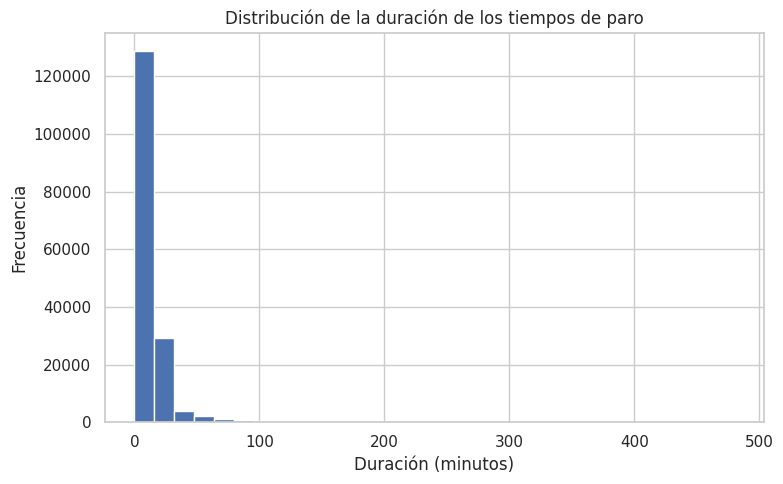

In [ ]:
# Distribución de la duración de los paros

plt.figure(figsize=(8,5))

plt.hist(
    df_paros["Duración"].dropna(),
    bins=30
)

plt.title("Distribución de la duración de los tiempos de paro")
plt.xlabel("Duración (minutos)")
plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()

### Interpretación

La distribución de la duración de los tiempos de paro presenta una marcada concentración de eventos de corta duración y una cola extendida hacia valores mayores.

La mediana de **10 minutos** indica que al menos la mitad de los eventos presenta una duración igual o inferior a este valor, mientras que la media de **16.43 minutos** es superior debido a la presencia de paros de mayor duración.

Esta distribución evidencia que, aunque la mayoría de los eventos son relativamente cortos, existen algunos paros prolongados que pueden representar un impacto importante sobre la disponibilidad del proceso. Por ello, en los siguientes análisis se examinará la duración de los paros según **motivo, máquina y turno**, con el fin de identificar los factores que concentran el mayor tiempo de interrupción.

## 5.2 Tiempo acumulado por motivo de paro

En este apartado se identifican los principales motivos de paro en función del tiempo total acumulado. Este análisis permite reconocer las causas que generan el mayor impacto sobre la disponibilidad del proceso productivo.

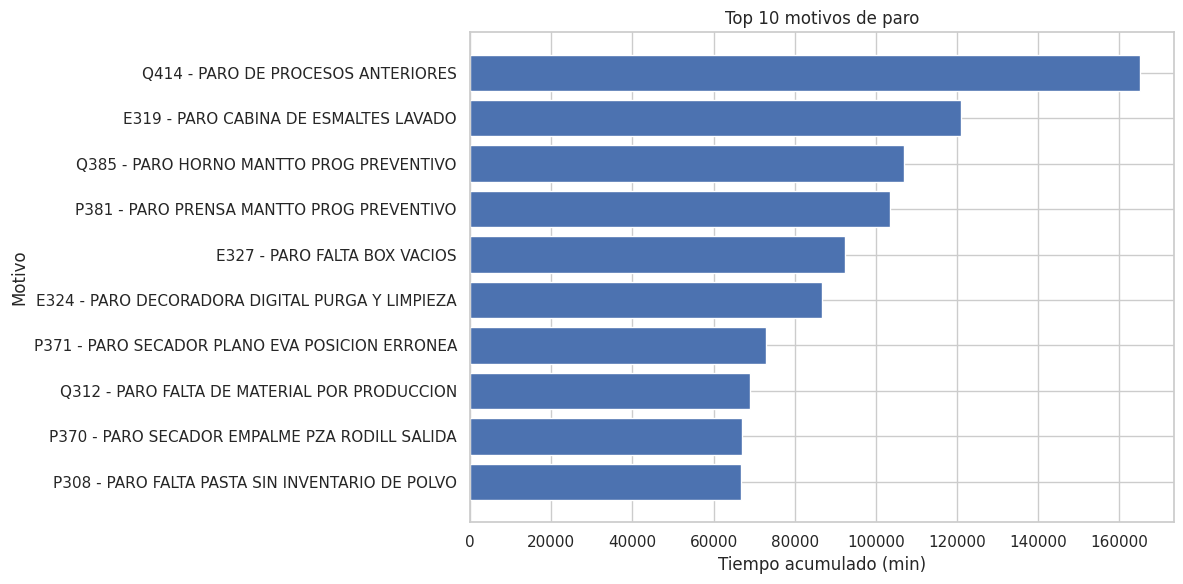

In [ ]:
# Top 10 motivos de paro por duración acumulada

top_motivos = (
    df_paros
    .groupby("Motivo")["Duración"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

plt.barh(
    top_motivos.index,
    top_motivos.values
)

plt.title("Top 10 motivos de paro")
plt.xlabel("Tiempo acumulado (min)")
plt.ylabel("Motivo")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### Interpretación

El análisis de los principales motivos de paro muestra que el tiempo de interrupción se concentra en un grupo reducido de causas.

El motivo **Q414 – PARO DE PROCESOS ANTERIORES** presenta el mayor tiempo acumulado, con aproximadamente **164,000 minutos**, seguido por **E319 – PARO CABINA DE ESMALTES LAVADO** y **Q385 – PARO HORNO MANTTO PROG PREVENTIVO**.

También destacan **P381 – PARO PRENSA MANTTO PROG PREVENTIVO** y **E327 – PARO FALTA BOX VACIOS**, que presentan tiempos acumulados superiores a 90,000 minutos.

Estos resultados permiten identificar los motivos que generan una mayor pérdida acumulada de tiempo operativo y proporcionan una primera base para priorizar su análisis. En particular, los motivos relacionados con procesos anteriores, mantenimiento y disponibilidad de recursos requieren una revisión más detallada en los análisis posteriores.

## 5.3 Diagrama de Pareto de los motivos de paro

Con el propósito de identificar las causas que generan la mayor parte del tiempo de paro, se construye un diagrama de Pareto. Este análisis permite priorizar los motivos de mayor impacto y orientar los esfuerzos de mejora hacia aquellos eventos que representan la mayor pérdida de disponibilidad del proceso.

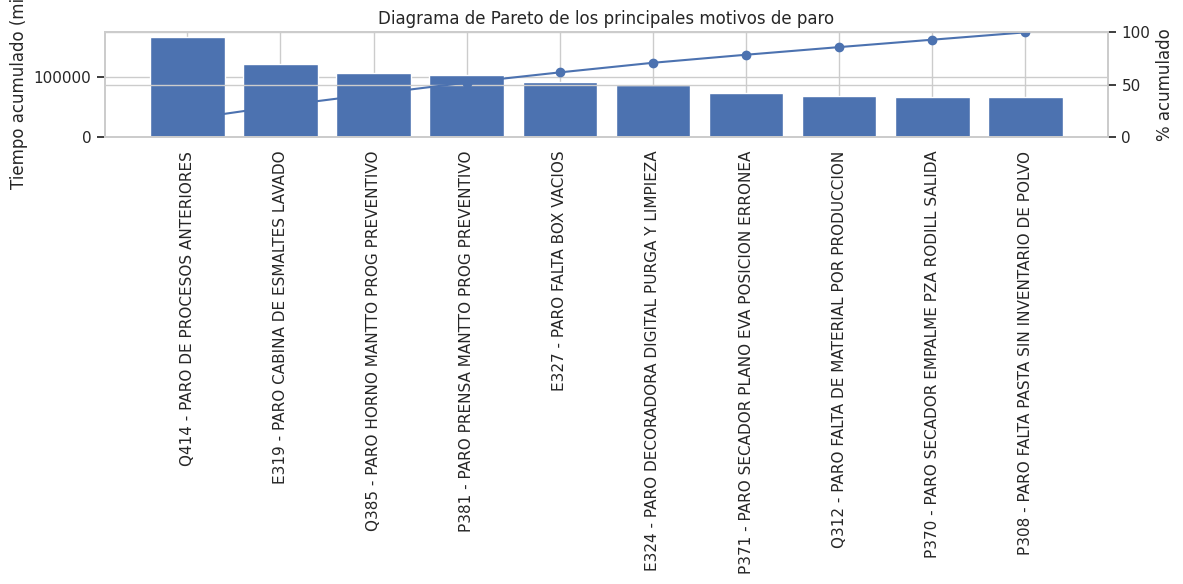

In [ ]:
# Top 10 motivos de paro
pareto = (
    df_paros
    .groupby("Motivo")["Duración"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

# Porcentaje y porcentaje acumulado del Top 10
pareto["Porcentaje"] = pareto["Duración"] / pareto["Duración"].sum() * 100
pareto["% Acumulado"] = pareto["Porcentaje"].cumsum()

fig, ax1 = plt.subplots(figsize=(12,6))

ax1.bar(pareto["Motivo"], pareto["Duración"])

ax1.set_ylabel("Tiempo acumulado (min)")
ax1.tick_params(axis="x", rotation=90)

ax2 = ax1.twinx()

ax2.plot(
    pareto["Motivo"],
    pareto["% Acumulado"],
    marker="o"
)

ax2.set_ylabel("% acumulado")
ax2.set_ylim(0,100)

plt.title("Diagrama de Pareto de los principales motivos de paro")

plt.tight_layout()
plt.show()

### Interpretación

El diagrama de Pareto muestra que el tiempo acumulado de paro se concentra en un grupo reducido de motivos.

Los cuatro primeros motivos representan aproximadamente el **52 % del tiempo total acumulado** dentro de los diez principales motivos analizados. Al considerar los siete primeros motivos, se alcanza aproximadamente el **79 %**, mientras que con los ocho primeros se supera el **85 %**.

Entre las causas con mayor contribución destacan **Q414 – PARO DE PROCESOS ANTERIORES**, **E319 – PARO CABINA DE ESMALTES LAVADO**, **Q385 – PARO HORNO MANTTO PROG PREVENTIVO** y **P381 – PARO PRENSA MANTTO PROG PREVENTIVO**.

Estos resultados permiten establecer una primera priorización de las causas de paro, concentrando el análisis posterior en los motivos que acumulan la mayor cantidad de tiempo de interrupción.

# 6. Integración de los conjuntos de datos

Una vez realizado el análisis exploratorio de los conjuntos de datos de Producción y Tiempos de paro, se procede a su integración con el objetivo de construir una fuente de información unificada.

La integración permitirá relacionar los registros de producción con los eventos de paro mediante variables comunes, facilitando el análisis conjunto del comportamiento productivo y de las interrupciones del proceso.

## 6.1 Preparación de las variables de unión

Para realizar la integración de los conjuntos de datos, se identifican las variables que permiten relacionar los registros de Producción y Tiempos de paro. Las variables consideradas para establecer la correspondencia son la fecha, la máquina y el turno.

## 6.2 Verificación de las claves de integración

Antes de integrar ambos conjuntos de datos, se verifica que la variable Máquina presente la misma nomenclatura en Producción y Tiempos de paro. Esta comprobación permite asegurar que los registros puedan relacionarse correctamente mediante esta variable.

In [ ]:
# Máquinas presentes en ambos datasets

print("Producción")
print(sorted(df_produccion["Máquina"].unique()))

print("\nTiempos de paro")
print(sorted(df_paros["Máquina"].unique()))

Producción
['Horno 1', 'Horno 2', 'Horno 3', 'Horno 4 Inferior', 'Horno 4 Superior', 'Linea 6 New', 'Línea 1', 'Línea 2', 'Línea 3', 'Línea 4', 'Línea 5', 'Línea 7', 'Prensa 1', 'Prensa 2', 'Prensa 3', 'Prensa 4', 'Prensa 5', 'Prensa 6 New', 'Prensa 7 New', 'Prensa 8', 'Prensa 9']

Tiempos de paro
['Horno 1', 'Horno 2', 'Horno 3', 'Horno 4 Inferior', 'Horno 4 Superior', 'Linea 6 New', 'Línea 1', 'Línea 2', 'Línea 3', 'Línea 4', 'Línea 5', 'Línea 7', 'Prensa 1', 'Prensa 2', 'Prensa 3', 'Prensa 4', 'Prensa 5', 'Prensa 6 New', 'Prensa 7 New', 'Prensa 8', 'Prensa 9']


### Interpretación

La comparación de los valores únicos de Máquina muestra que las máquinas presentes en los conjuntos de Producción y Tiempos de paro coinciden. Esto confirma que la variable puede utilizarse como parte de las variables de integración entre ambos conjuntos de datos.

La coincidencia en la nomenclatura evita problemas de correspondencia derivados de diferencias en los nombres de las máquinas.

## 6.3 Comprobación de la granularidad

Antes de integrar los datasets, se analiza el número de registros existentes para cada combinación de fecha, máquina y turno. Esta comprobación permite identificar diferencias en la granularidad de ambos conjuntos de datos y determinar si es necesario realizar una agregación previa para evitar duplicaciones durante la integración.

In [ ]:
# Número de registros por fecha, máquina y turno

registros_prod = (
    df_produccion
    .groupby(["Fecha Turno", "Máquina", "Turno"])
    .size()
    .reset_index(name="Registros")
)

registros_paros = (
    df_paros
    .groupby(["Fecha", "Máquina", "Turno"])
    .size()
    .reset_index(name="Registros")
)

print("Producción")
print(registros_prod["Registros"].describe())

print("\nTiempos de paro")
print(registros_paros["Registros"].describe())

Producción
count   59532.00
mean        2.14
std         2.61
min         1.00
25%         1.00
50%         1.00
75%         2.00
max        30.00
Name: Registros, dtype: float64

Tiempos de paro
count   46757.00
mean        3.62
std         2.47
min         1.00
25%         2.00
50%         3.00
75%         5.00
max        30.00
Name: Registros, dtype: float64


### Interpretación

La comprobación muestra que ambos conjuntos de datos presentan múltiples registros para una misma combinación de fecha, máquina y turno. En Producción se obtiene un promedio de **2.14 registros**, mientras que en Tiempos de paro el promedio es de **3.62 registros** por combinación.

Estos resultados evidencian que los datasets no presentan la misma granularidad y que no existe una correspondencia uno a uno entre sus registros. Por ello, es necesario considerar una agregación previa a la integración para evitar la multiplicación de registros y la duplicación de valores durante la unión.

## 6.4 Agregación de los conjuntos de datos

Debido a que los dos datasets presentan diferentes cantidades de registros para una misma combinación de fecha, máquina y turno, se realiza una agregación previa a este nivel de granularidad. De esta forma, se obtiene un único registro por cada combinación y se evita la duplicación de información durante la integración.

In [ ]:
# AGREGACIÓN DE PRODUCCIÓN

# Normalizar nombres y tipos de las variables numéricas
columnas_numericas = [
    "Piezas buenas prensadas a SAP",
    "M2 buenos prensados a SAP",
    "Piezas malas prensadas a SAP",
    "M2 malos prensados a SAP",
    "Piezas buenas esmaltadas a SAP",
    "M2 buenos esmaltados a SAP",
    "Piezas malas esmaltadas a SAP",
    "M2 malos esmaltados a SAP",
    "Piezas buenas quemadas a SAP",
    "M2 buenos quemadas a SAP",
    "Tiempo operacion",
    "Velocidad"
]

for col in columnas_numericas:
    if col in df_produccion.columns:
        df_produccion[col] = pd.to_numeric(
            df_produccion[col],
            errors="coerce"
        ).fillna(0)


# CREAR LAS VARIABLES UNIFICADAS

maquina = (
    df_produccion["Máquina"]
    .astype(str)
    .str.strip()
    .str.lower()
)


# PIEZAS BUENAS A SAP

df_produccion["Piezas buenas a SAP"] = np.select(
    [
        maquina.str.contains("prensa", na=False),
        maquina.str.contains("línea|linea", regex=True, na=False),
        maquina.str.contains("horno", na=False)
    ],
    [
        df_produccion["Piezas buenas prensadas a SAP"],
        df_produccion["Piezas buenas esmaltadas a SAP"],
        df_produccion["Piezas buenas quemadas a SAP"]
    ],
    default=0
)



# M2 BUENOS A SAP

df_produccion["M2 buenos a SAP"] = np.select(
    [
        maquina.str.contains("prensa", na=False),
        maquina.str.contains("línea|linea", regex=True, na=False),
        maquina.str.contains("horno", na=False)
    ],
    [
        df_produccion["M2 buenos prensados a SAP"],
        df_produccion["M2 buenos esmaltados a SAP"],
        df_produccion["M2 buenos quemadas a SAP"]
    ],
    default=0
)


# PIEZAS MALAS A SAP

df_produccion["Piezas malas a SAP"] = np.select(
    [
        maquina.str.contains("prensa", na=False),
        maquina.str.contains("línea|linea", regex=True, na=False)
    ],
    [
        df_produccion["Piezas malas prensadas a SAP"],
        df_produccion["Piezas malas esmaltadas a SAP"]
    ],
    default=0
)


# M2 MALOS A SAP

df_produccion["M2 malos a SAP"] = np.select(
    [
        maquina.str.contains("prensa", na=False),
        maquina.str.contains("línea|linea", regex=True, na=False)
    ],
    [
        df_produccion["M2 malos prensados a SAP"],
        df_produccion["M2 malos esmaltados a SAP"]
    ],
    default=0
)


# AGREGACIÓN FINAL

produccion_agregada = (
    df_produccion
    .groupby(["Fecha Turno", "Máquina", "Turno"])
    .agg({
        "Piezas buenas a SAP": "sum",
        "M2 buenos a SAP": "sum",
        "Piezas malas a SAP": "sum",
        "M2 malos a SAP": "sum",
        "Tiempo operacion": "sum",
        "Velocidad": "mean"
    })
    .reset_index()
    .rename(columns={"Fecha Turno": "Fecha"})
)

# Agregación de Tiempos de paro

paros_agregados = (
    df_paros
    .groupby(["Fecha", "Máquina", "Turno"])
    .agg({
        "Duración": "sum",
        "Motivo": "count"
    })
    .reset_index()
    .rename(
        columns={
            "Duración": "Duración total paro",
            "Motivo": "Número de paros"
        }
    )
)

print("Producción agregada:", produccion_agregada.shape)
print("Paros agregados:", paros_agregados.shape)

Producción agregada: (59532, 9)
Paros agregados: (46757, 5)


### Interpretación

La agregación permite llevar ambos conjuntos de datos a un nivel común de análisis definido por fecha, máquina y turno. Como resultado, Producción queda representado por **59,532 registros agregados**, mientras que Tiempos de paro contiene **46,757 registros agregados**.

En Producción, las variables de volumen y tiempo de operación se agregan mediante suma, mientras que la velocidad se resume mediante su promedio. En Tiempos de paro, la duración se acumula y se contabiliza el número de registros para representar la cantidad de eventos de paro correspondientes a cada combinación.

Esta transformación establece una estructura compatible para la integración posterior y evita que las diferencias en el número de registros originales generen duplicaciones o distorsiones en los indicadores.

## 6.5 Integración de los datasets

Una vez agregados ambos conjuntos al mismo nivel de granularidad, se integran mediante fecha, máquina y turno. El resultado permite relacionar los indicadores de producción con los tiempos y frecuencia de los paros registrados.

In [ ]:
# Integración de Producción y Tiempos de paro

df_integrado = pd.merge(
    produccion_agregada,
    paros_agregados,
    on=["Fecha", "Máquina", "Turno"],
    how="left"
)

print("Dimensiones del dataset integrado:", df_integrado.shape)

display(df_integrado.head())

Dimensiones del dataset integrado: (59532, 11)


,Fecha,Máquina,Turno,Piezas buenas a SAP,M2 buenos a SAP,Piezas malas a SAP,M2 malos a SAP,Tiempo operacion,Velocidad,Duración total paro,Número de paros
0,2024-01-01,Horno 1,1,14970,2878.85,0,0.00,480,3177.00,33.00,7.00
1,2024-01-01,Horno 1,2,9469,1820.96,0,0.00,480,3177.00,198.00,8.00
2,2024-01-01,Horno 1,3,14342,2758.08,0,0.00,480,3177.00,52.00,12.00
3,2024-01-01,Horno 2,1,15339,2949.81,0,0.00,480,3171.00,21.00,6.00
4,2024-01-01,Horno 2,2,14855,2856.73,0,0.00,480,3170.00,35.00,14.00


### Interpretación

La integración final conserva los 59,532 registros correspondientes al nivel de análisis de fecha, máquina y turno. Los datos de producción quedan relacionados con la duración total y el número de paros registrados, permitiendo analizar conjuntamente el comportamiento productivo y las interrupciones del proceso.

### 6.6 Validación del dataset integrado

Finalmente, se comprueba que el dataset integrado conserve el número de registros esperado y se identifican los valores nulos presentes en las variables resultantes de la integración. Esta revisión permite determinar qué variables requieren tratamiento durante la etapa de preparación.

In [ ]:
# Validación final del dataset integrado

print("Registros integrados:", len(df_integrado))

print("\nValores nulos:")
display(
    df_integrado.isnull().sum()
    .to_frame("Nulos")
    .query("Nulos > 0")
)

Registros integrados: 59532

Valores nulos:


,Nulos
Duración total paro,12778
Número de paros,12778


### Interpretación

La validación confirma que el dataset integrado conserva los **59,532 registros** esperados. Se identifican **12,778 valores nulos** tanto en Duración total paro como en Número de paros, correspondientes a combinaciones de fecha, máquina y turno sin registros asociados de tiempos de paro.

Estos resultados deben considerarse durante la etapa de preparación y modelado. En particular, los valores nulos de las variables de paro deberán diferenciarse de los valores faltantes de otras variables, ya que la ausencia de un registro de paro puede representar que no se registraron eventos de paro para esa combinación.

# 7. Análisis del dataset integrado
Una vez realizada la integración de los datos de producción y tiempos de paro, se procede al análisis exploratorio del dataset resultante. El objetivo es identificar patrones de comportamiento relacionados con el nivel de producción, los tiempos de operación y las interrupciones del proceso, considerando las variables de fecha, máquina y turno. Este análisis permitirá identificar posibles relaciones entre la producción y los tiempos de paro, así como variables relevantes para las etapas posteriores del proyecto.

## 7.1 Resumen general del dataset integrado

Como primera etapa del análisis del dataset integrado, se revisan sus principales características estadísticas con el propósito de conocer la escala de los datos y el comportamiento general de las variables productivas y de los tiempos de paro.

In [ ]:
# 7.1 Resumen general de las principales variables del dataset integrado

variables_descriptivas_integrado = [
    "Piezas buenas a SAP",
    "M2 buenos a SAP",
    "Piezas malas a SAP",
    "M2 malos a SAP",
    "Tiempo operacion",
    "Duración total paro",
    "Número de paros"
]

print("Dimensiones del dataset integrado:", df_integrado.shape)

estadisticas_integrado = (
    df_integrado[variables_descriptivas_integrado]
    .describe()
    .T
)

estadisticas_integrado = estadisticas_integrado[
    ["mean", "50%", "std", "min", "max"]
]

estadisticas_integrado.columns = [
    "Media",
    "Mediana",
    "Desv. estándar",
    "Mínimo",
    "Máximo"
]

display(
    estadisticas_integrado.round(2)
)

Dimensiones del dataset integrado: (59532, 11)


,Media,Mediana,Desv. estándar,Mínimo,Máximo
Piezas buenas a SAP,8432.87,8188.00,4128.83,0.00,33138.00
M2 buenos a SAP,1904.48,1732.69,692.48,0.00,4440.90
Piezas malas a SAP,45.77,13.00,89.44,0.00,2353.00
M2 malos a SAP,10.36,2.92,19.26,0.00,537.79
Tiempo operacion,480.24,480.00,15.67,119.00,1440.00
Duración total paro,59.53,40.00,69.68,0.00,872.00
Número de paros,3.62,3.00,2.47,1.00,30.00


### Interpretación

El dataset integrado está compuesto por 59,532 registros y 11 variables correspondientes a combinaciones de fecha, máquina y turno. La caracterización descriptiva se concentra en las principales variables cuantitativas de producción y paro, evitando incluir variables de identificación o variables cuya interpretación depende de la máquina.

Los resultados permiten observar la variabilidad existente en los indicadores de producción y en los tiempos de paro. Estas características proporcionan una visión general del comportamiento del proceso integrado y sirven como base para los análisis específicos por máquina, turno y condiciones de paro.

## 7.2 Producción acumulada por máquina

Se analiza la producción acumulada en metros cuadrados para cada máquina con el propósito de identificar los equipos que concentran el mayor volumen producido dentro del periodo analizado.

,M2 producidos
Máquina,
Horno 4 Superior,7884347.66
Línea 7,7785704.09
Horno 3,7613578.28
Linea 6 New,7613277.38
Horno 4 Inferior,7491263.44
Horno 2,7331033.80
Horno 1,7286999.57
Prensa 1,4647575.20
Línea 1,4598518.45


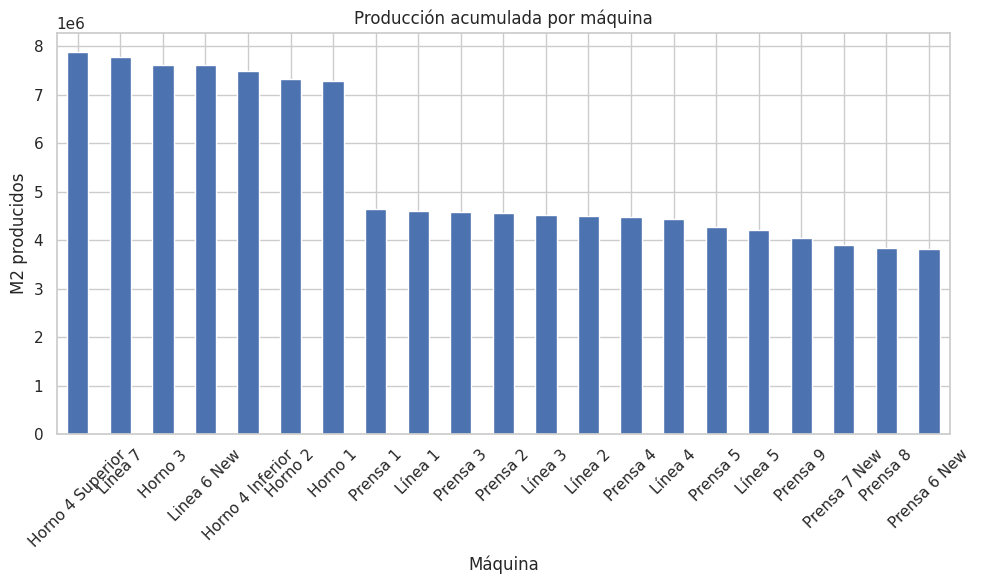

In [ ]:
# 7.2 Producción acumulada por máquina

produccion_maquina = (
    df_integrado
    .groupby("Máquina")["M2 buenos a SAP"]
    .sum()
    .sort_values(ascending=False)
)

display(
    produccion_maquina
    .to_frame("M2 producidos")
    .round(2)
)

plt.figure(figsize=(10, 6))

produccion_maquina.plot(kind="bar")

plt.title("Producción acumulada por máquina")
plt.xlabel("Máquina")
plt.ylabel("M2 producidos")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Interpretación

La producción total presenta diferencias entre las máquinas analizadas. Los mayores volúmenes corresponden a Horno 4 Superior, Línea 7 y Línea 6 New, con aproximadamente 7.87, 7.77 y 7.60 millones de M² producidos, respectivamente.

Estos resultados permiten identificar las máquinas que concentran el mayor volumen de producción durante el periodo analizado. Sin embargo, el volumen total producido por sí solo no permite determinar cuál máquina presenta el mejor desempeño operativo.

## 7.3 Tiempos de paro por máquina

Se analiza el tiempo total de paro por máquina con el propósito de identificar los equipos que concentran una mayor cantidad de tiempo improductivo. Este análisis permite localizar los equipos que requieren mayor atención desde la perspectiva de las interrupciones del proceso.

,Minutos de paro
Máquina,
Horno 2,193604.00
Prensa 5,186371.00
Horno 1,182829.00
Línea 4,174906.00
Línea 5,171463.00
Línea 3,165400.00
Prensa 2,163381.00
Línea 1,157169.00
Línea 2,154849.00


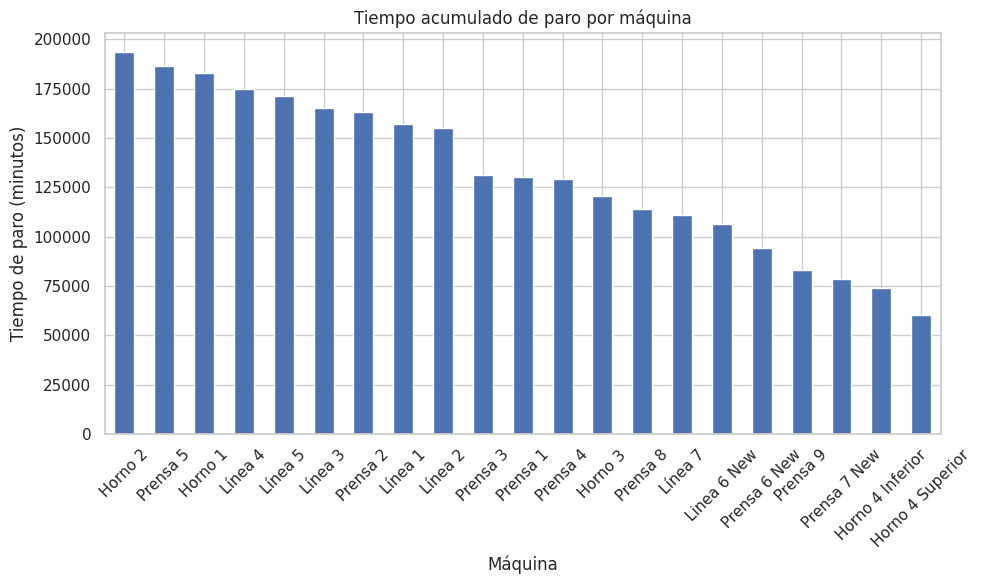

In [ ]:
# 7.3 Tiempos de paro por máquina

paros_maquina = (
    df_integrado
    .groupby("Máquina")["Duración total paro"]
    .sum()
    .sort_values(ascending=False)
)

display(paros_maquina.to_frame("Minutos de paro").round(2))

plt.figure(figsize=(10, 6))

paros_maquina.plot(kind="bar")

plt.title("Tiempo acumulado de paro por máquina")
plt.xlabel("Máquina")
plt.ylabel("Tiempo de paro (minutos)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Interpretación

El tiempo acumulado de paro presenta diferencias importantes entre los equipos. Los mayores valores corresponden a **Horno 2, Prensa 5, Horno 1, Línea 4 y Línea 5**, que concentran los mayores tiempos de interrupción registrados durante el periodo analizado. Estos resultados permiten identificar los equipos que presentan una mayor acumulación de tiempo de paro y que pueden considerarse prioritarios para un análisis posterior de las causas de interrupción.

## 7.4 Producción por turno

Se compara la producción acumulada entre los tres turnos de operación mediante los metros cuadrados prensados. El objetivo es identificar diferencias en el volumen producido según el turno y determinar si existe un comportamiento productivo diferenciado entre ellos.

,M2 producidos
Turno,
3,38154921.55
2,37882530.26
1,37340075.94


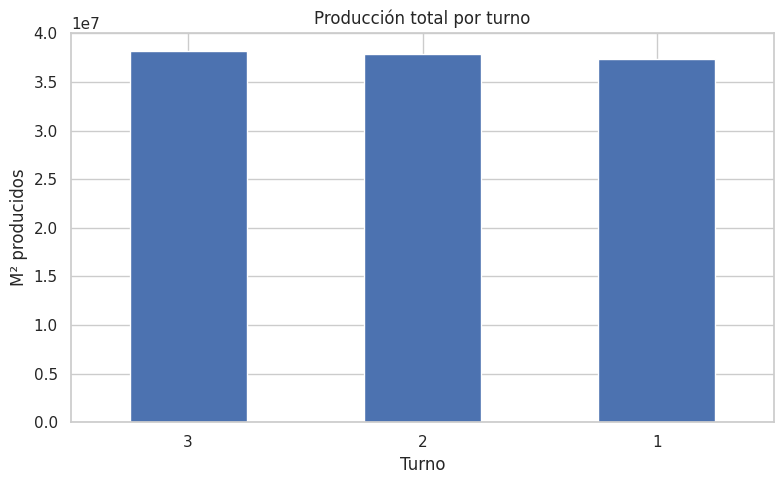

In [ ]:
# 7.4 Producción por turno

produccion_turno = (
    df_integrado
    .groupby("Turno")["M2 buenos a SAP"]
    .sum()
    .sort_values(ascending=False)
)

display(
    produccion_turno
    .to_frame("M2 producidos")
    .round(2)
)

plt.figure(figsize=(8, 5))

produccion_turno.plot(kind="bar")

plt.title("Producción total por turno")
plt.xlabel("Turno")
plt.ylabel("M² producidos")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Interpretación

La producción total presenta valores relativamente similares entre los tres turnos. El **turno 3** registra el mayor volumen producido, seguido por el **turno 2** y el **turno 1**. Aunque existen diferencias, estas no representan por sí mismas una conclusión sobre el desempeño de los turnos, ya que también pueden estar relacionadas con la distribución temporal de la operación y las condiciones particulares de producción.

## 7.5 Relación entre producción y tiempos de paro

Se analiza gráficamente la relación entre la duración acumulada de los tiempos de paro y los metros cuadrados prensados para cada registro. El objetivo es identificar posibles patrones entre las interrupciones del proceso y el volumen de producción.

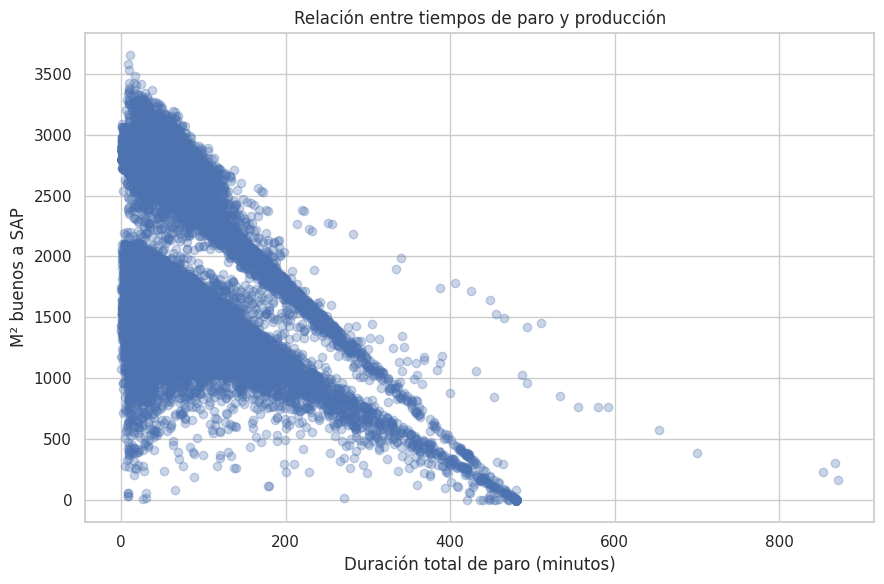

In [ ]:
# 7.5 Relación entre producción y tiempos de paro

plt.figure(figsize=(9, 6))

plt.scatter(
    df_integrado["Duración total paro"],
    df_integrado["M2 buenos a SAP"],
    alpha=0.3
)

plt.title("Relación entre tiempos de paro y producción")
plt.xlabel("Duración total de paro (minutos)")
plt.ylabel("M² buenos a SAP")
plt.tight_layout()

plt.show()

### Interpretación

La producción total presenta valores relativamente similares entre los tres turnos. El turno 3 registra el mayor volumen producido, seguido por el turno 2 y el turno 1. Aunque existen diferencias, estas no representan por sí mismas una conclusión sobre el desempeño de los turnos, ya que también pueden estar relacionadas con la distribución temporal de la operación y las condiciones particulares de producción.

## 7.6 Matriz de correlación

Se analiza la correlación entre las principales variables productivas y los tiempos de paro. El objetivo es identificar relaciones lineales entre las variables y determinar cuáles presentan asociaciones relevantes con el comportamiento del proceso.

,Piezas buenas a SAP,M2 buenos a SAP,Piezas malas a SAP,M2 malos a SAP,Tiempo operacion,Velocidad,Duración total paro,Número de paros
Piezas buenas a SAP,1.00,0.72,0.04,-0.05,-0.01,0.48,-0.41,0.47
M2 buenos a SAP,0.72,1.00,-0.06,-0.02,-0.00,0.61,-0.49,0.36
Piezas malas a SAP,0.04,-0.06,1.00,0.94,-0.00,-0.29,0.08,-0.04
M2 malos a SAP,-0.05,-0.02,0.94,1.00,-0.00,-0.30,0.08,-0.03
Tiempo operacion,-0.01,-0.00,-0.00,-0.00,1.00,-0.00,0.01,0.00
Velocidad,0.48,0.61,-0.29,-0.30,-0.00,1.00,-0.03,0.48
Duración total paro,-0.41,-0.49,0.08,0.08,0.01,-0.03,1.00,0.07
Número de paros,0.47,0.36,-0.04,-0.03,0.00,0.48,0.07,1.00


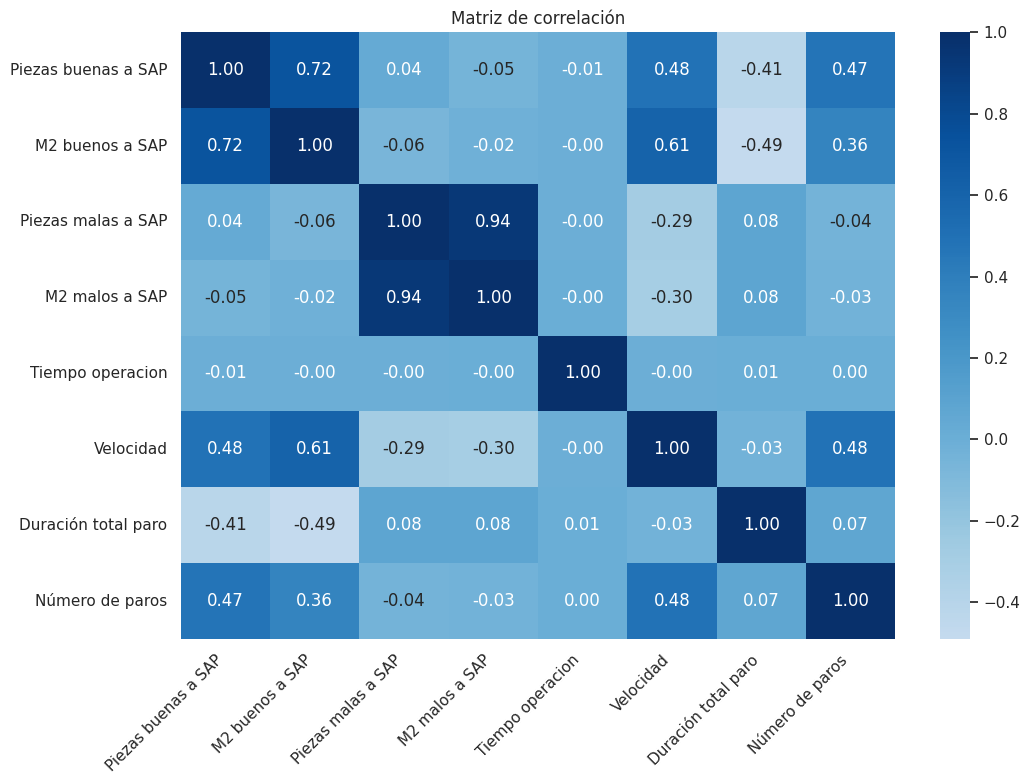

In [ ]:
# 7.6 Matriz de correlación

variables_correlacion = [
    "Piezas buenas a SAP",
    "M2 buenos a SAP",
    "Piezas malas a SAP",
    "M2 malos a SAP",
    "Tiempo operacion",
    "Velocidad",
    "Duración total paro",
    "Número de paros"
]

# Cálculo de la matriz de correlación
correlacion = df_integrado[variables_correlacion].corr()

# Mostrar matriz numérica
display(correlacion.round(2))

# Gráfico de la matriz de correlación
plt.figure(figsize=(11, 8))

sns.heatmap(
    correlacion,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    center=0
)

plt.title("Matriz de correlación")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Interpretación

La matriz de correlación permite identificar las relaciones lineales entre las variables productivas y los indicadores de paro del dataset integrado. Se observa una relación positiva muy elevada entre M2 buenos a SAP y Piezas buenas a SAP (0.72), debido a que ambas variables representan medidas estrechamente relacionadas con el volumen de producción.

También se observan asociaciones entre la Velocidad, las variables productivas y los indicadores de paro. Destaca la relación entre Velocidad y M2 buenos a SAP (0.61). Sin embargo, estas relaciones deben interpretarse con cautela, ya que la velocidad depende de las características y condiciones de operación de cada máquina.

La Duración total paro y el Número de paros permiten complementar el análisis productivo con información sobre las interrupciones del proceso. No obstante, las correlaciones representan únicamente asociaciones lineales y no permiten establecer relaciones de causalidad.

## 8. Preparación de variables para el análisis
A partir de los resultados obtenidos en el análisis exploratorio, se realiza la preparación de las variables que serán utilizadas en las etapas posteriores del proyecto. Esta etapa comprende la selección de las variables relevantes, la revisión de sus tipos de datos y la transformación de aquellas variables necesarias para facilitar el análisis y la construcción de modelos posteriores.

## 8.1 Selección de variables relevantes

Para las etapas posteriores del análisis se seleccionan las variables relacionadas directamente con la producción y los tiempos de paro. Se consideran como variables principales los metros cuadrados prensados, las piezas buenas y malas prensadas a SAP, el tiempo de operación, la velocidad, la duración total de los paros y el número de paros.

In [ ]:
# 8.1 Selección de variables relevantes

variables_analisis = [
    "Fecha",
    "Máquina",
    "Turno",
    "Piezas buenas a SAP",
    "M2 buenos a SAP",
    "Piezas malas a SAP",
    "M2 malos a SAP",
    "Tiempo operacion",
    "Velocidad",
    "Duración total paro",
    "Número de paros"
]

df_analisis = df_integrado[variables_analisis].copy()

print("Dimensiones del dataset para el análisis:", df_analisis.shape)

display(df_analisis.head())

Dimensiones del dataset para el análisis: (59532, 11)


,Fecha,Máquina,Turno,Piezas buenas a SAP,M2 buenos a SAP,Piezas malas a SAP,M2 malos a SAP,Tiempo operacion,Velocidad,Duración total paro,Número de paros
0,2024-01-01,Horno 1,1,14970,2878.85,0,0.00,480,3177.00,33.00,7.00
1,2024-01-01,Horno 1,2,9469,1820.96,0,0.00,480,3177.00,198.00,8.00
2,2024-01-01,Horno 1,3,14342,2758.08,0,0.00,480,3177.00,52.00,12.00
3,2024-01-01,Horno 2,1,15339,2949.81,0,0.00,480,3171.00,21.00,6.00
4,2024-01-01,Horno 2,2,14855,2856.73,0,0.00,480,3170.00,35.00,14.00


### Interpretación
Las variables seleccionadas corresponden a los principales indicadores de producción y tiempos de paro, considerando además las variables de identificación de fecha, máquina y turno. El dataset resultante conserva 59,532 registros y 11 variables, manteniendo la estructura necesaria para los análisis posteriores.

La selección permite concentrar el análisis en las variables relacionadas directamente con el comportamiento productivo y las interrupciones del proceso, evitando incorporar variables que no sean necesarias para las etapas posteriores.

## 8.2 Tratamiento de valores nulos

Se revisan los valores nulos presentes en las variables seleccionadas para determinar el tratamiento más adecuado. En particular, los valores faltantes de las variables de paro representan combinaciones de fecha, máquina y turno sin un evento de paro registrado, por lo que pueden interpretarse como ausencia de paro.

In [ ]:
# 8.2 Tratamiento de valores nulos

df_analisis["Duración total paro"] = (
    df_analisis["Duración total paro"].fillna(0)
)

df_analisis["Número de paros"] = (
    df_analisis["Número de paros"].fillna(0)
)

print("Valores nulos después del tratamiento:")

display(
    df_analisis.isnull().sum()
    .to_frame("Nulos")
    .query("Nulos > 0")
)

Valores nulos después del tratamiento:


,Nulos


### Interpretación

Los valores nulos de Duración total paro y Número de paros se sustituyen por cero debido a que corresponden a combinaciones de fecha, máquina y turno para las cuales no se encontró un evento de paro durante la integración.

De esta manera, la ausencia de un registro de paro se representa como 0 minutos de paro y 0 eventos, permitiendo incorporar estas observaciones al análisis sin tratarlas como datos faltantes.

Después del tratamiento, no se identificaron valores nulos en las variables seleccionadas para el análisis, por lo que el dataset queda preparado para las etapas posteriores de creación de variables y modelado.

## 8.3 Creación de variables derivadas
Se generan variables adicionales a partir de los indicadores existentes para facilitar la interpretación del desempeño productivo. Estas variables permitirán relacionar la producción con los tiempos de operación y los eventos de paro.

In [ ]:
# 8.3 Creación de variables derivadas

# Porcentaje de piezas buenas respecto al total producido
df_analisis["% Piezas buenas"] = np.where(
    (df_analisis["Piezas buenas a SAP"] + df_analisis["Piezas malas a SAP"]) > 0,
    (
        df_analisis["Piezas buenas a SAP"]
        /
        (
            df_analisis["Piezas buenas a SAP"]
            + df_analisis["Piezas malas a SAP"]
        )
        * 100
    ),
    0
)

# Porcentaje de piezas malas respecto al total producido
df_analisis["% Piezas malas"] = np.where(
    (df_analisis["Piezas buenas a SAP"] + df_analisis["Piezas malas a SAP"]) > 0,
    (
        df_analisis["Piezas malas a SAP"]
        /
        (
            df_analisis["Piezas buenas a SAP"]
            + df_analisis["Piezas malas a SAP"]
        )
        * 100
    ),
    0
)

# Tiempo de paro en horas
df_analisis["Horas de paro"] = (
    df_analisis["Duración total paro"] / 60
)

# Indicador de presencia de paro
df_analisis["Tiene paro"] = (
    df_analisis["Número de paros"] > 0
).astype(int)

# Mostrar variables derivadas
display(
    df_analisis[
        [
            "Máquina",
            "Piezas buenas a SAP",
            "Piezas malas a SAP",
            "% Piezas buenas",
            "% Piezas malas",
            "Horas de paro",
            "Tiene paro"
        ]
    ].head()
)

,Máquina,Piezas buenas a SAP,Piezas malas a SAP,% Piezas buenas,% Piezas malas,Horas de paro,Tiene paro
0,Horno 1,14970,0,100.00,0.00,0.55,1
1,Horno 1,9469,0,100.00,0.00,3.30,1
2,Horno 1,14342,0,100.00,0.00,0.87,1
3,Horno 2,15339,0,100.00,0.00,0.35,1
4,Horno 2,14855,0,100.00,0.00,0.58,1


### Interpretación

Las variables derivadas permiten complementar la información original del dataset. El porcentaje de piezas buenas facilita evaluar el comportamiento de la producción respecto al total prensado, mientras que las horas de paro permiten expresar la duración de las interrupciones en una unidad temporal más interpretable. Por su parte, la variable `Tiene paro` permite diferenciar los registros con presencia de eventos de paro de aquellos en los que no se registraron interrupciones.

## 8.4 Clasificación del nivel de paro

Para facilitar el análisis de los tiempos de paro, se incorpora una clasificación basada en la duración acumulada de los paros registrada para cada combinación de fecha, máquina y turno. Se establecen cuatro rangos de duración que permiten segmentar la severidad de los eventos de paro.

In [ ]:
# 8.4 Clasificación del nivel de paro

df_analisis["Nivel de paro"] = pd.cut(
    df_analisis["Duración total paro"],
    bins=[-1, 30, 60, 120, float("inf")],
    labels=[
        "Bajo",
        "Medio",
        "Alto",
        "Muy alto"
    ]
)

distribucion_nivel_paro = (
    df_analisis["Nivel de paro"]
    .value_counts()
    .reindex(["Bajo", "Medio", "Alto", "Muy alto"])
    .fillna(0)
    .astype(int)
)

display(
    distribucion_nivel_paro.to_frame("Número de registros")
)

,Número de registros
Nivel de paro,
Bajo,30848
Medio,14477
Alto,9594
Muy alto,4613


### Interpretación

La clasificación permite transformar la duración continua de los paros en cuatro categorías operativas: Bajo, Medio, Alto y Muy alto. Esta transformación facilita la interpretación de los resultados y permite posteriormente definir una variable objetivo para el análisis de clasificación.

Los límites de 30, 60 y 120 minutos se utilizan como criterios de segmentación definidos para este análisis, permitiendo diferenciar distintos niveles de duración total acumulada de paro.

## 8.5 Distribución de los niveles de paro

A partir de la clasificación anterior, se analiza la frecuencia de cada nivel de paro para identificar la distribución de las condiciones de operación según la duración acumulada de los tiempos de paro.

In [ ]:
# 8.5 Distribución de los niveles de paro

distribucion_paros = (
    df_analisis["Nivel de paro"]
    .value_counts()
    .reindex(["Bajo", "Medio", "Alto", "Muy alto"])
    .fillna(0)
    .astype(int)
)

print("Distribución de los niveles de paro:")
display(distribucion_paros.to_frame("Número de registros"))

Distribución de los niveles de paro:


,Número de registros
Nivel de paro,
Bajo,30848
Medio,14477
Alto,9594
Muy alto,4613


### Interpretación

La distribución muestra una mayor concentración de registros en la categoría Bajo, con 30,848 observaciones, seguida de Medio, con 14,477 registros. Las categorías Alto y Muy alto presentan 9,594 y 4,613 registros, respectivamente.

En conjunto, los niveles Bajo y Medio concentran la mayor cantidad de observaciones, mientras que Alto y Muy alto presentan una menor frecuencia dentro del conjunto de datos. Esta distribución permite caracterizar inicialmente el comportamiento de los niveles de paro antes de realizar la transformación de la variable para el modelado predictivo.

## 8.6 Visualización de la distribución de los niveles de paro

La distribución de los niveles de paro se representa gráficamente para facilitar la identificación de la frecuencia con la que se presentan las diferentes categorías de duración acumulada de los paros.

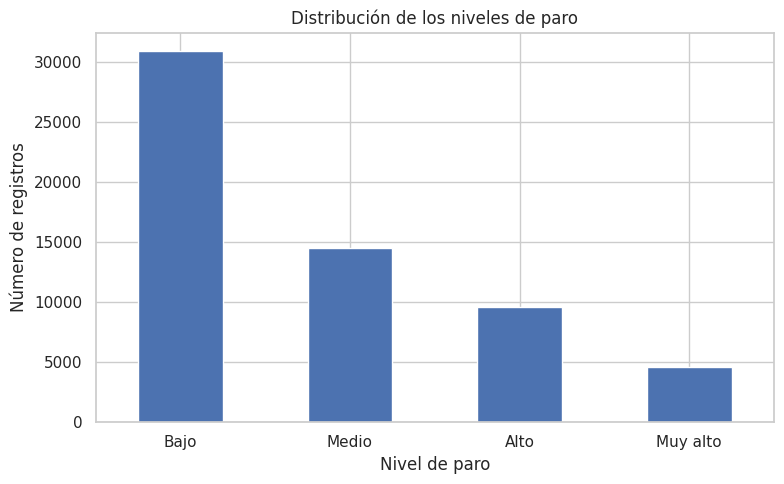

In [ ]:
# 8.6 Distribución de los niveles de paro

plt.figure(figsize=(8, 5))

distribucion_paros.plot(kind="bar")

plt.title("Distribución de los niveles de paro")
plt.xlabel("Nivel de paro")
plt.ylabel("Número de registros")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Interpretación

A partir de la distribución de los niveles de paro se construyó la variable objetivo binaria Paro_alto, agrupando las categorías Alto y Muy alto como clase positiva, mientras que Bajo y Medio se consideraron como clase negativa. Esta transformación permitió plantear el problema como una clasificación binaria orientada a identificar registros asociados con niveles elevados de paro.

La nueva variable objetivo presenta un desbalance entre las clases, por lo que esta característica fue considerada posteriormente durante la partición de los datos, el entrenamiento del modelo y la evaluación de su desempeño.

# 9. Definición de la variable objetivo y modelado

## 9.1 Definición de la variable objetivo

A partir de la clasificación de los tiempos de paro realizada previamente, se define una variable objetivo binaria que permitirá diferenciar las condiciones con niveles de paro bajos de aquellas que presentan una afectación elevada. Esta variable servirá como base para las etapas posteriores de modelado.

In [ ]:
# 9.1 Definición de la variable objetivo

df_modelo = df_analisis.copy()

df_modelo["Paro_alto"] = (
    df_modelo["Nivel de paro"]
    .isin(["Alto", "Muy alto"])
    .astype(int)
)

print("Distribución de la variable objetivo:")

display(
    df_modelo["Paro_alto"]
    .value_counts()
    .sort_index()
    .to_frame("Número de registros")
)

Distribución de la variable objetivo:


,Número de registros
Paro_alto,
0,45325
1,14207


### Interpretación

La variable objetivo presenta 45,325 registros de la clase 0 y 14,207 registros de la clase 1. Esto confirma la existencia de un desbalance entre las clases, ya que la clase asociada a niveles altos de paro representa una proporción menor del conjunto de datos.

Las categorías Bajo y Medio corresponden a la clase 0, mientras que Alto y Muy alto corresponden a la clase 1. Esta transformación permite plantear el problema como una clasificación binaria orientada a identificar situaciones asociadas con niveles elevados de paro.

## 9.2 Selección de variables predictoras

Para el modelado se seleccionan variables relacionadas con las condiciones de producción y operación que pueden aportar información sobre la aparición de niveles elevados de paro. Se excluyen las variables derivadas directamente de los tiempos de paro, ya que su utilización como predictores produciría fuga de información y afectaría la validez del modelo.

In [ ]:
# 9.2 Selección de variables predictoras

variables_predictoras = [
    "M2 buenos a SAP",
    "Piezas buenas a SAP",
    "Piezas malas a SAP",
    "Tiempo operacion",
    "Velocidad"
]

X = df_modelo[variables_predictoras].copy()
y = df_modelo["Paro_alto"].copy()

print("Variables predictoras:")
print(variables_predictoras)

print("\nDimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

display(X.head())

Variables predictoras:
['M2 buenos a SAP', 'Piezas buenas a SAP', 'Piezas malas a SAP', 'Tiempo operacion', 'Velocidad']

Dimensiones de X: (59532, 5)
Dimensiones de y: (59532,)


,M2 buenos a SAP,Piezas buenas a SAP,Piezas malas a SAP,Tiempo operacion,Velocidad
0,2878.85,14970,0,480,3177.00
1,1820.96,9469,0,480,3177.00
2,2758.08,14342,0,480,3177.00
3,2949.81,15339,0,480,3171.00
4,2856.73,14855,0,480,3170.00


### Interpretación

Se seleccionaron cinco variables predictoras relacionadas con el comportamiento productivo: M2 buenos a SAP, Piezas buenas a SAP, Piezas malas a SAP, Tiempo operación y Velocidad. El conjunto de datos mantiene los 59,532 registros, por lo que la selección de variables no implica pérdida de observaciones.

## 9.3 División del conjunto de datos

El conjunto de datos se divide en dos subconjuntos: entrenamiento y prueba. El 80 % de los registros se utiliza para entrenar el modelo, mientras que el 20 % restante se reserva para evaluar su capacidad de generalización sobre datos no utilizados durante el entrenamiento.

In [ ]:
# 9.3 División del conjunto de datos

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

print("\nDistribución de la variable objetivo en entrenamiento:")
print(y_train.value_counts())

print("\nDistribución de la variable objetivo en prueba:")
print(y_test.value_counts())

Datos de entrenamiento: (47625, 5)
Datos de prueba: (11907, 5)

Distribución de la variable objetivo en entrenamiento:
Paro_alto
0    36260
1    11365
Name: count, dtype: int64

Distribución de la variable objetivo en prueba:
Paro_alto
0    9065
1    2842
Name: count, dtype: int64


### Interpretación

La división genera **47,625 registros para entrenamiento** y **11,907 para prueba**, equivalentes aproximadamente al 80 % y 20 % del conjunto total. El uso de `stratify` permite conservar la proporción de las clases de la variable objetivo en ambos subconjuntos, lo cual es especialmente importante debido al desequilibrio existente entre los registros de paro alto y el resto.

## 9.4 Entrenamiento del modelo de clasificación

Se emplea un modelo Random Forest para clasificar las condiciones de operación en función de la presencia de niveles elevados de paro. Este algoritmo permite capturar relaciones no lineales entre las variables productivas y operativas y proporciona información sobre la importancia relativa de las variables utilizadas.

In [ ]:
# 9.4 Entrenamiento del modelo de clasificación

from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

modelo_rf.fit(X_train, y_train)

print("Modelo Random Forest entrenado correctamente.")

Modelo Random Forest entrenado correctamente.


### Interpretación

El modelo Random Forest se entrenó correctamente utilizando 100 árboles y ponderación balanceada de las clases. Esta configuración busca reducir el efecto del **desbalance entre las clases** durante el proceso de clasificación.

## 9.5 Evaluación del modelo

El modelo entrenado se evalúa utilizando el conjunto de prueba, que contiene registros no utilizados durante el entrenamiento. Se calculan métricas de clasificación para determinar su capacidad para identificar correctamente las condiciones de paro alto.

In [ ]:
# 9.5 Evaluación del modelo de clasificación

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Predicciones sobre el conjunto de prueba
y_pred = modelo_rf.predict(X_test)

# Métricas de evaluación
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("Métricas del modelo Random Forest:")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

# Matriz de confusión
matriz = confusion_matrix(y_test, y_pred)

print("\nMatriz de confusión:")
print(matriz)

# Reporte de clasificación
print("\nReporte de clasificación:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Bajo / Medio", "Alto / Muy alto"],
    zero_division=0
))

Métricas del modelo Random Forest:
Accuracy:  0.8131
Precision: 0.6226
Recall:    0.5514
F1-score:  0.5848

Matriz de confusión:
[[8115  950]
 [1275 1567]]

Reporte de clasificación:
                 precision    recall  f1-score   support

   Bajo / Medio       0.86      0.90      0.88      9065
Alto / Muy alto       0.62      0.55      0.58      2842

       accuracy                           0.81     11907
      macro avg       0.74      0.72      0.73     11907
   weighted avg       0.81      0.81      0.81     11907



### Interpretación

El modelo Random Forest obtuvo una exactitud global de 0.8131 sobre el conjunto de prueba, lo que significa que clasificó correctamente aproximadamente el 81.3 % de las 11,907 observaciones evaluadas.

Para la clase Alto / Muy alto, correspondiente a la variable objetivo Paro_alto = 1, el modelo obtuvo una precision de 0.6226, un recall de 0.5514 y un F1-score de 0.5848. El recall indica que el modelo logró identificar aproximadamente el 55.1 % de los casos reales de paro alto, mientras que la precision indica que aproximadamente el 62.3 % de las observaciones clasificadas como paro alto realmente pertenecían a esta clase.

La matriz de confusión permite complementar esta interpretación. De las observaciones pertenecientes a la clase Bajo / Medio, 8,115 fueron clasificadas correctamente, mientras que 950 fueron identificadas incorrectamente como paro Alto / Muy alto. Para la clase Alto / Muy alto, 1,567 casos fueron identificados correctamente, mientras que 1,275 casos reales de paro alto fueron clasificados como Bajo / Medio.

Los 1,275 falsos negativos representan un aspecto relevante para el proyecto, debido a que corresponden a situaciones de paro alto que el modelo no logró detectar. Esto muestra que, aunque el modelo presenta una accuracy superior al 80 %, todavía existe margen de mejora en la identificación de la clase de mayor interés.

Debido al desbalance existente entre las clases, la evaluación no debe basarse únicamente en la accuracy. Por ello, resulta conveniente analizar diferentes umbrales de clasificación para determinar si es posible incrementar la detección de casos de paro alto, aun cuando esto implique aceptar un mayor número de falsos positivos.

## 9.6 Matriz de confusión

La matriz de confusión permite analizar con mayor detalle el comportamiento del modelo de clasificación, diferenciando entre las predicciones correctas e incorrectas para cada clase. Esta evaluación es especialmente importante debido al desbalance de la variable objetivo, ya que permite observar la capacidad del modelo para identificar correctamente los registros correspondientes a niveles altos de paro.

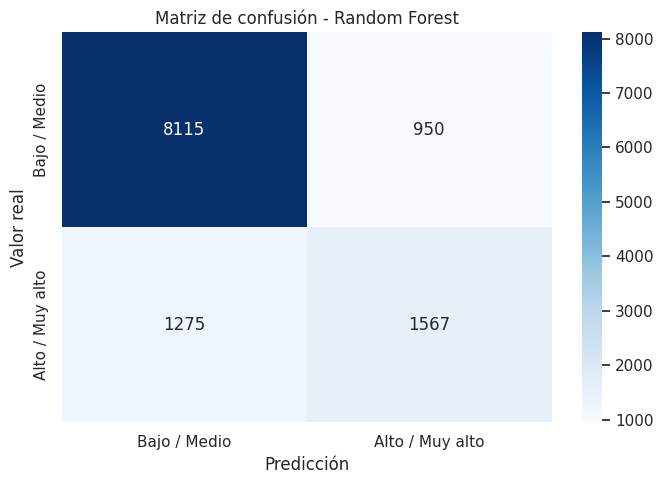

In [ ]:
# 9.6 Matriz de confusión

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

matriz_confusion = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    matriz_confusion,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Bajo / Medio", "Alto / Muy alto"],
    yticklabels=["Bajo / Medio", "Alto / Muy alto"]
)

plt.title("Matriz de confusión - Random Forest")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.tight_layout()
plt.show()

### Interpretación

El modelo Random Forest obtuvo una accuracy de 0.8131 sobre el conjunto de prueba. Para la clase Alto / Muy alto, correspondiente a Paro_alto = 1, se obtuvo una precision de 0.6226, un recall de 0.5514 y un F1-score de 0.5848.

La matriz de confusión muestra 8,115 verdaderos negativos, 950 falsos positivos, 1,275 falsos negativos y 1,567 verdaderos positivos. Los falsos negativos son particularmente relevantes, ya que representan casos reales de paro alto que el modelo clasificó como Bajo / Medio.

El recall de 0.5514 indica que el modelo identifica aproximadamente el 55.1 % de los casos reales de paro alto, mientras que la precision de 0.6226 indica que aproximadamente el 62.3 % de las observaciones clasificadas como paro alto corresponden realmente a esta clase.

Estos resultados indican un desempeño moderado con el umbral de 0.50. Debido a que el objetivo del proyecto es identificar situaciones de mayor nivel de paro, resulta conveniente evaluar diferentes umbrales de decisión para determinar si puede incrementarse la detección de estos casos.

## 9.7 Importancia de las variables

Para complementar la evaluación del modelo, se analiza la importancia relativa de las variables predictoras utilizadas por el algoritmo Random Forest. Esta información permite identificar cuáles variables tienen mayor contribución en la clasificación de los registros según su nivel de paro.

,Variable,Importancia
0,M2 buenos a SAP,0.34
1,Piezas buenas a SAP,0.33
4,Velocidad,0.17
2,Piezas malas a SAP,0.16
3,Tiempo operacion,0.00


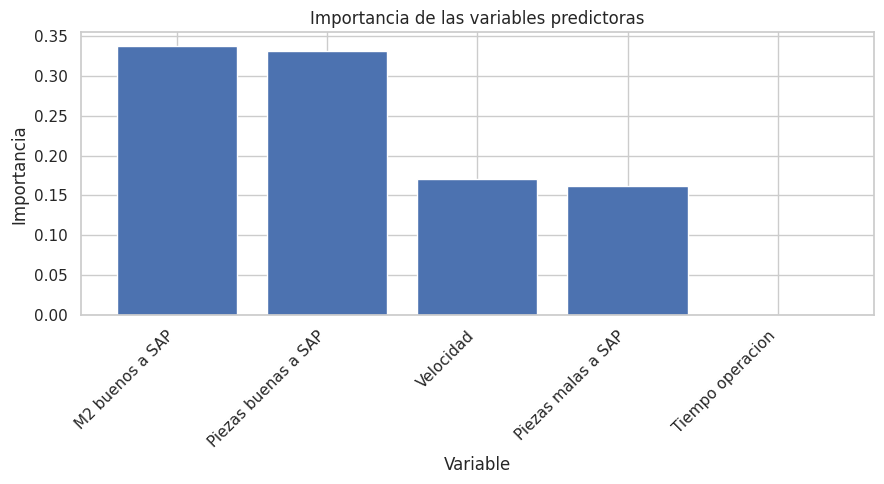

In [ ]:
# 9.7 Importancia de las variables predictoras

import pandas as pd
import matplotlib.pyplot as plt

importancias = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": modelo_rf.feature_importances_
})

importancias = importancias.sort_values(
    by="Importancia",
    ascending=False
)

display(importancias)

# Gráfica
plt.figure(figsize=(9, 5))

plt.bar(
    importancias["Variable"],
    importancias["Importancia"]
)

plt.title("Importancia de las variables predictoras")
plt.xlabel("Variable")
plt.ylabel("Importancia")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Interpretación

Los resultados muestran que la variable con mayor importancia para el modelo es M2 buenos a SAP, con un valor de 0.34, seguida de Piezas buenas a SAP, con una importancia de 0.33. En tercer lugar se encuentra Velocidad, con 0.17, mientras que Piezas malas a SAP presenta una importancia de 0.16.

Por su parte, Tiempo operación presenta una importancia de 0.00, por lo que su contribución relativa dentro del modelo es prácticamente nula.

En conjunto, los resultados indican que las variables relacionadas con la producción de piezas y metros cuadrados buenos, así como la velocidad, tienen mayor relevancia para diferenciar las condiciones asociadas a niveles altos de paro.

## 9.8 Capacidad de discriminación del modelo

Además de las métricas obtenidas mediante un umbral de clasificación fijo, se analiza la capacidad del modelo para distinguir entre registros con niveles altos de paro y registros sin niveles altos de paro. Para ello se utiliza la curva ROC y el área bajo la curva (ROC-AUC).

ROC-AUC: 0.8701


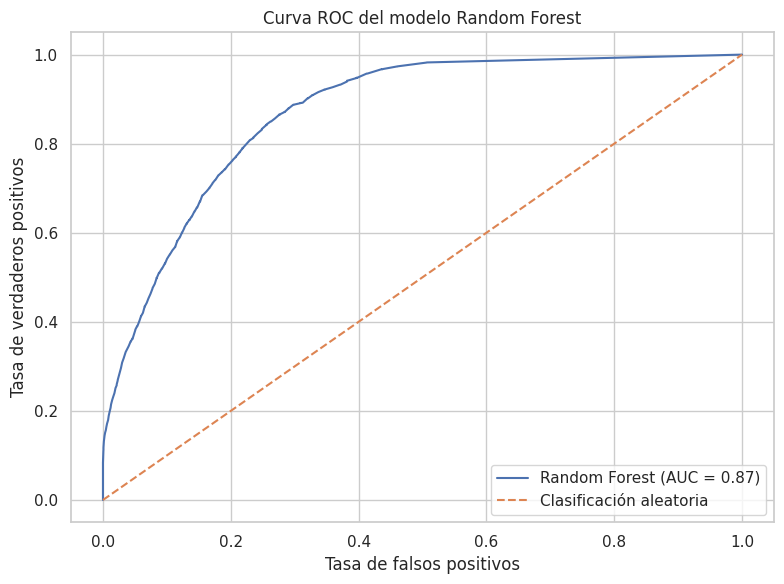

In [ ]:
# 9.8 Capacidad de discriminación del modelo

from sklearn.metrics import roc_curve, roc_auc_score

# Probabilidad de pertenecer a la clase 1
y_prob = modelo_rf.predict_proba(X_test)[:, 1]

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_prob)

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

print(f"ROC-AUC: {roc_auc:.4f}")

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC = {roc_auc:.2f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Clasificación aleatoria"
)

plt.title("Curva ROC del modelo Random Forest")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.legend()

plt.tight_layout()
plt.show()

### Interpretación

La curva ROC permite evaluar la capacidad del modelo Random Forest para distinguir entre las condiciones de paro bajo y paro alto, considerando diferentes umbrales de clasificación. El modelo obtuvo un valor de ROC-AUC de 0.8701, lo que indica una buena capacidad de discriminación entre ambas clases. La curva se encuentra claramente por encima de la línea correspondiente a una clasificación aleatoria, indicando que el modelo presenta un desempeño significativamente superior al de un clasificador sin capacidad discriminativa.

## 9.9 Ajuste del umbral de clasificación

Debido al **desbalance existente entre las clases** de la variable objetivo, se analiza el efecto de modificar el umbral de clasificación utilizado por el modelo. El objetivo es identificar un punto de decisión que permita mejorar el equilibrio entre la precisión y la capacidad de detección de los registros con niveles elevados de paro.

In [ ]:
# 9.9 Optimización del umbral de clasificación

from sklearn.metrics import precision_recall_curve

# Probabilidades de la clase Paro alto
y_prob = modelo_rf.predict_proba(X_test)[:, 1]

# Precision, recall y umbrales
precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob
)

# F1 para cada umbral
f1_scores = (
    2 * precision[:-1] * recall[:-1]
    / (precision[:-1] + recall[:-1] + 1e-10)
)

# Mejor umbral
indice_mejor = f1_scores.argmax()

mejor_umbral = thresholds[indice_mejor]
mejor_precision = precision[indice_mejor]
mejor_recall = recall[indice_mejor]
mejor_f1 = f1_scores[indice_mejor]

print(f"Mejor umbral: {mejor_umbral:.4f}")
print(f"Precision:     {mejor_precision:.4f}")
print(f"Recall:        {mejor_recall:.4f}")
print(f"F1-score:      {mejor_f1:.4f}")

Mejor umbral: 0.2395
Precision:     0.5243
Recall:        0.8082
F1-score:      0.6360


### Interpretación

Debido al desbalance existente entre las clases de la variable objetivo, se analiza el comportamiento del modelo utilizando diferentes umbrales de clasificación. Para cada umbral se calculan las métricas de precisión, recall y F1-score, seleccionando posteriormente aquel que maximiza el F1-score. El análisis identificó como mejor umbral un valor de 0.2395, con una precisión de 0.5243, un recall de 0.8082 y un F1-score de 0.6360.

Estos resultados indican que la reducción del umbral respecto al valor convencional de 0.50 permite incrementar la capacidad del modelo para identificar casos de paro alto, alcanzando un recall de 80.82 %, aunque con una precisión menor. Por lo tanto, el umbral de 0.2395 representa la configuración seleccionada para lograr un mejor equilibrio entre precisión y recall, de acuerdo con el criterio de maximización del F1-score.

## 9.10 Evaluación del modelo con el umbral ajustado

Se evalúa nuevamente el modelo utilizando el umbral de clasificación obtenido en el análisis anterior. Esta comparación permite determinar el efecto del ajuste sobre la identificación de los registros con niveles elevados de paro.

In [ ]:
# 9.10 Evaluación con el umbral ajustado

y_pred_ajustado = (
    y_prob >= mejor_umbral
).astype(int)

print("Métricas con umbral ajustado")
print("----------------------------")

print(
    f"Precision: {precision_score(y_test, y_pred_ajustado):.4f}"
)

print(
    f"Recall:    {recall_score(y_test, y_pred_ajustado):.4f}"
)

print(
    f"F1-score:  {f1_score(y_test, y_pred_ajustado):.4f}"
)

print("\nMatriz de confusión:")

display(
    pd.DataFrame(
        confusion_matrix(y_test, y_pred_ajustado),
        index=["Real 0", "Real 1"],
        columns=["Predicho 0", "Predicho 1"]
    )
)

Métricas con umbral ajustado
----------------------------
Precision: 0.5243
Recall:    0.8082
F1-score:  0.6360

Matriz de confusión:


,Predicho 0,Predicho 1
Real 0,6981,2084
Real 1,545,2297


### Interpretación

Se realizó una nueva evaluación del modelo Random Forest utilizando el umbral seleccionado en el análisis anterior, correspondiente a 0.2395. Con este ajuste se obtuvo una precision de 0.5243, un recall de 0.8082 y un F1-score de 0.6360.

El recall de 0.8082 indica que el modelo identifica correctamente aproximadamente el 80.82 % de los casos reales de paro alto. De acuerdo con la matriz de confusión, de los 2,842 registros pertenecientes a la clase de paro alto, 2,297 fueron identificados correctamente, mientras que 545 fueron clasificados como paro bajo o medio.

Por otra parte, se obtuvieron 2,084 falsos positivos, correspondientes a observaciones que realmente pertenecen a la clase de paro bajo o medio, pero que fueron clasificadas por el modelo como paro alto. Este resultado es consistente con la disminución de la precision, ya que al reducir el umbral se incrementa la sensibilidad del modelo, pero también aumenta la cantidad de falsas alarmas.

En comparación con el umbral convencional de 0.50, el recall aumenta de 0.5514 a 0.8082, mientras que la precision disminuye de 0.6226 a 0.5243. El F1-score, por su parte, mejora de 0.5848 a 0.6360.

Estos resultados indican que el ajuste del umbral favorece la detección de situaciones de paro alto, reduciendo la cantidad de casos de esta clase que el modelo no identifica. Por ello, el umbral de 0.2395 resulta apropiado cuando se busca priorizar la detección de condiciones de mayor nivel de paro, aun aceptando un incremento en las falsas alarmas.

## 9.11 Conclusiones del modelo Random Forest

El modelo Random Forest presentó una buena capacidad de discriminación, con un ROC-AUC de 0.8701, lo que indica que el modelo posee una capacidad adecuada para diferenciar entre registros con niveles de paro bajo y alto.

Las variables con mayor importancia dentro del modelo fueron M2 buenos a SAP (0.34), Piezas buenas a SAP (0.33) y Velocidad (0.17). En menor medida, Piezas malas a SAP presentó una importancia de 0.16, mientras que Tiempo operación tuvo una importancia de 0.00. En conjunto, estos resultados indican que las variables relacionadas con el volumen de producción y la velocidad del proceso tienen una mayor contribución para diferenciar las condiciones asociadas con paro alto.

Con el umbral convencional de 0.50, el modelo obtuvo una accuracy de 0.8131, una precision de 0.6226, un recall de 0.5514 y un F1-score de 0.5848 para la clase de paro alto. Debido al desbalance existente entre las clases, se analizaron diferentes umbrales de decisión para buscar un mejor equilibrio entre precisión y recall.

Mediante este análisis se seleccionó como mejor umbral un valor de 0.2395, con una precision de 0.5243, un recall de 0.8082 y un F1-score de 0.6360. El ajuste del umbral permitió incrementar de manera importante la capacidad del modelo para identificar registros correspondientes a la clase de paro alto, aunque con una disminución de la precisión.

La matriz de confusión con el umbral ajustado muestra que el modelo clasificó correctamente 2,297 de los 2,842 registros reales de paro alto, mientras que 545 registros de esta clase fueron clasificados como paro bajo o medio. Asimismo, se identificaron 2,084 falsos positivos, correspondientes a registros de paro bajo o medio clasificados como paro alto.

En conjunto, los resultados muestran que el modelo Random Forest es capaz de identificar patrones asociados con condiciones de paro elevado y puede utilizarse como herramienta de apoyo para el análisis del comportamiento del proceso productivo. El ajuste del umbral mejora principalmente la detección de los casos de paro alto, por lo que resulta útil cuando se busca reducir la cantidad de casos de esta clase que no son identificados por el modelo. Sin embargo, los resultados deben interpretarse como un apoyo para el análisis y la toma de decisiones, y no como una clasificación definitiva de las condiciones operativas.

# 10. Conclusiones del análisis y modelado

El análisis exploratorio permitió caracterizar e integrar los conjuntos de datos de Producción y Tiempos de paro, obteniendo un dataset integrado de 59,532 registros a nivel de fecha, máquina y turno. La integración permitió relacionar los indicadores productivos con la duración y frecuencia de los eventos de paro, proporcionando una visión conjunta del comportamiento del proceso productivo.

El análisis por máquina mostró diferencias importantes tanto en el volumen acumulado de producción como en el comportamiento de los tiempos de paro. Estas diferencias permiten identificar equipos con distintos niveles de producción e interrupciones, lo que representa un punto de partida para realizar análisis específicos sobre el comportamiento de cada equipo y sus condiciones operativas.

El análisis exploratorio mostró una mayor concentración de registros en los niveles bajos de paro. La clasificación de la duración acumulada de los paros permitió establecer cuatro niveles: Bajo, Medio, Alto y Muy alto. Esta distribución evidenció que los registros correspondientes a niveles elevados de paro representan una proporción menor del conjunto de datos, por lo que el desbalance entre las clases debía considerarse durante el desarrollo del modelo.

La matriz de correlación permitió identificar relaciones relevantes entre las variables productivas y los indicadores de paro. Destaca la relación entre Piezas buenas a SAP y M2 buenos a SAP, así como la relación entre M2 buenos a SAP y Velocidad. También se observó una relación negativa entre M2 buenos a SAP y Duración total de paro. Estas relaciones representan asociaciones lineales y no permiten establecer relaciones de causalidad.

A partir de la clasificación de los niveles de paro se definió la variable objetivo binaria Paro_alto, considerando como clase positiva los registros correspondientes a los niveles Alto y Muy alto. La distribución obtenida fue de 45,325 registros de clase 0 y 14,207 registros de clase 1, evidenciando un desbalance entre las clases. Para conservar esta proporción durante el modelado, los datos se dividieron mediante una partición estratificada en 47,625 registros para entrenamiento y 11,907 para prueba.

Para la clasificación se desarrolló un modelo Random Forest, utilizando como variables predictoras M2 buenos a SAP, Piezas buenas a SAP, Piezas malas a SAP, Tiempo operación y Velocidad. El modelo se configuró con 100 árboles y ponderación balanceada de las clases, con el objetivo de reducir el efecto del desbalance existente.

Con el umbral convencional de 0.50, el modelo obtuvo una accuracy de 0.8131, precision de 0.6226, recall de 0.5514 y F1-score de 0.5848 para la clase de paro alto. Estos resultados muestran una capacidad moderada para identificar correctamente los registros correspondientes a niveles altos de paro utilizando el umbral convencional.

La evaluación mediante la curva ROC mostró un ROC-AUC de 0.8701, lo que indica una buena capacidad de discriminación entre las clases. Este resultado muestra que el modelo posee capacidad para diferenciar registros asociados con niveles bajos o medios de paro respecto de aquellos correspondientes a niveles altos, considerando diferentes umbrales de decisión.

El análisis de importancia de variables mostró que las variables con mayor contribución al modelo fueron M2 buenos a SAP (0.34), Piezas buenas a SAP (0.33) y Velocidad (0.17). Posteriormente se ubicó Piezas malas a SAP (0.16), mientras que Tiempo operación (0.00) presentó una contribución prácticamente nula dentro del modelo. En conjunto, estos resultados indican que las variables relacionadas con el volumen de producción y la velocidad presentan una mayor relevancia para diferenciar las condiciones asociadas con niveles altos de paro.

Debido al desbalance entre las clases, se analizaron diferentes umbrales de clasificación con el propósito de mejorar la detección de los registros correspondientes a paro alto. El análisis identificó como mejor umbral un valor de 0.2395, con una precision de 0.5243, recall de 0.8082 y F1-score de 0.6360. En comparación con el umbral convencional de 0.50, este ajuste permitió incrementar considerablemente el recall y mejorar el F1-score, aunque implicó una reducción de la precisión.

La matriz de confusión obtenida con el umbral ajustado mostró 6,981 verdaderos negativos, 2,084 falsos positivos, 545 falsos negativos y 2,297 verdaderos positivos. Por lo tanto, el modelo logró identificar correctamente 2,297 de los 2,842 registros reales correspondientes a la clase de paro alto, mientras que 545 registros de esta clase fueron clasificados como paro bajo o medio.

En conjunto, los resultados muestran que la integración de los datos, el análisis exploratorio y el modelo Random Forest permiten obtener información útil sobre el comportamiento del proceso productivo y sobre las condiciones asociadas con niveles elevados de paro. El modelo presenta una buena capacidad de discriminación general, respaldada por un ROC-AUC de 0.8701, mientras que el ajuste del umbral permite mejorar considerablemente la detección de casos de paro alto.

Sin embargo, el modelo todavía presenta falsos positivos y falsos negativos, por lo que sus resultados deben considerarse como una herramienta de apoyo para el análisis y la toma de decisiones, y no como un mecanismo definitivo para determinar las causas de los paros. Como trabajo futuro, se recomienda profundizar en el análisis de las variables operativas, estudiar el comportamiento específico de cada equipo, incorporar nuevas variables que puedan aportar información sobre los eventos de paro y evaluar otras estrategias de modelado que permitan mejorar la identificación de condiciones de paro elevado.

# 11. Exportación del dataset final para el dashboard

## 11.1 Preparación del dataset final para el dashboard

La preparación del dataset final tiene como objetivo generar una versión del conjunto de datos integrada y enriquecida con los resultados del modelo de clasificación, que posteriormente será utilizada para la construcción del dashboard en Power BI.

A partir del dataset seleccionado para el análisis, se incorporan las probabilidades estimadas por el modelo Random Forest para la clase de paro alto, así como la clasificación resultante utilizando el umbral seleccionado de 0.2395. Adicionalmente, se genera una variable categórica denominada Nivel paro predicho, que permite interpretar los resultados del modelo en dos categorías: Bajo / Medio y Alto / Muy alto.

El dataset final contiene 59,532 registros y 19 variables, incluyendo información de fecha, máquina, turno, indicadores de producción, duración y frecuencia de los paros, porcentajes de piezas, horas de paro y las variables generadas por el modelo.

La incorporación de estas variables permite que el dashboard no solo presente indicadores históricos del proceso productivo, sino que también facilite la visualización de las predicciones y probabilidades asociadas a condiciones de paro alto, proporcionando información adicional para el análisis y seguimiento del comportamiento operativo.

In [ ]:
# 11.1 Preparación del dataset final para el dashboard

df_dashboard = df_analisis.copy()

# Predicción de paro alto
df_dashboard["Probabilidad paro alto"] = (
    modelo_rf.predict_proba(
        df_dashboard[variables_predictoras]
    )[:, 1]
)

# Clasificación utilizando el umbral seleccionado
df_dashboard["Predicción paro alto"] = (
    df_dashboard["Probabilidad paro alto"] >= mejor_umbral
).astype(int)

# Nivel de paro predicho
df_dashboard["Nivel paro predicho"] = np.where(
    df_dashboard["Predicción paro alto"] == 1,
    "Alto / Muy alto",
    "Bajo / Medio"
)

# Exportar CSV
ruta_csv = "dataset_dashboard_final.csv"

df_dashboard.to_csv(
    ruta_csv,
    index=False,
    encoding="utf-8-sig"
)

print(f"CSV generado correctamente: {ruta_csv}")
print(f"Dimensiones: {df_dashboard.shape}")

display(df_dashboard.head())

CSV generado correctamente: dataset_dashboard_final.csv
Dimensiones: (59532, 19)


,Fecha,Máquina,Turno,Piezas buenas a SAP,M2 buenos a SAP,Piezas malas a SAP,M2 malos a SAP,Tiempo operacion,Velocidad,Duración total paro,Número de paros,% Piezas buenas,% Piezas malas,Horas de paro,Tiene paro,Nivel de paro,Probabilidad paro alto,Predicción paro alto,Nivel paro predicho
0,2024-01-01,Horno 1,1,14970,2878.85,0,0.00,480,3177.00,33.00,7.00,100.00,0.00,0.55,1,Medio,0.00,0,Bajo / Medio
1,2024-01-01,Horno 1,2,9469,1820.96,0,0.00,480,3177.00,198.00,8.00,100.00,0.00,3.30,1,Muy alto,0.98,1,Alto / Muy alto
2,2024-01-01,Horno 1,3,14342,2758.08,0,0.00,480,3177.00,52.00,12.00,100.00,0.00,0.87,1,Medio,0.00,0,Bajo / Medio
3,2024-01-01,Horno 2,1,15339,2949.81,0,0.00,480,3171.00,21.00,6.00,100.00,0.00,0.35,1,Bajo,0.00,0,Bajo / Medio
4,2024-01-01,Horno 2,2,14855,2856.73,0,0.00,480,3170.00,35.00,14.00,100.00,0.00,0.58,1,Medio,0.00,0,Bajo / Medio


### Interpretación

El dataset final fue generado correctamente con 59,532 registros y 19 variables. Además de conservar las variables productivas y los indicadores de paro, se incorporaron la Probabilidad paro alto, la Predicción paro alto y el Nivel paro predicho obtenidos mediante el modelo Random Forest y el umbral seleccionado de 0.2395.

Esta estructura permite utilizar el archivo como fuente de datos para el dashboard en Power BI, donde será posible analizar el comportamiento de la producción, los paros y las predicciones del modelo mediante indicadores y visualizaciones interactivas.

In [ ]:
print("Archivo final:", "dataset_dashboard_final.csv")
print("Registros:", len(df_dashboard))
print("Columnas:", len(df_dashboard.columns))

display(df_dashboard.head())
display(df_dashboard.dtypes)

Archivo final: dataset_dashboard_final.csv
Registros: 59532
Columnas: 19


,Fecha,Máquina,Turno,Piezas buenas a SAP,M2 buenos a SAP,Piezas malas a SAP,M2 malos a SAP,Tiempo operacion,Velocidad,Duración total paro,Número de paros,% Piezas buenas,% Piezas malas,Horas de paro,Tiene paro,Nivel de paro,Probabilidad paro alto,Predicción paro alto,Nivel paro predicho
0,2024-01-01,Horno 1,1,14970,2878.85,0,0.00,480,3177.00,33.00,7.00,100.00,0.00,0.55,1,Medio,0.00,0,Bajo / Medio
1,2024-01-01,Horno 1,2,9469,1820.96,0,0.00,480,3177.00,198.00,8.00,100.00,0.00,3.30,1,Muy alto,0.98,1,Alto / Muy alto
2,2024-01-01,Horno 1,3,14342,2758.08,0,0.00,480,3177.00,52.00,12.00,100.00,0.00,0.87,1,Medio,0.00,0,Bajo / Medio
3,2024-01-01,Horno 2,1,15339,2949.81,0,0.00,480,3171.00,21.00,6.00,100.00,0.00,0.35,1,Bajo,0.00,0,Bajo / Medio
4,2024-01-01,Horno 2,2,14855,2856.73,0,0.00,480,3170.00,35.00,14.00,100.00,0.00,0.58,1,Medio,0.00,0,Bajo / Medio


,0
Fecha,datetime64[ns]
Máquina,object
Turno,int64
Piezas buenas a SAP,int64
M2 buenos a SAP,float64
Piezas malas a SAP,int64
M2 malos a SAP,float64
Tiempo operacion,int64
Velocidad,float64
Duración total paro,float64
